<a href="https://colab.research.google.com/github/m4rt1v4l/Firm-fundamentals-Stock-Screener/blob/main/segmentacion_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Screener de acciones NYSE/NASDAQ -- fundamentales, segmentación K-Medoids y validación

**Entradas:** parquets de precios (`precios_filtrado.parquet`) y fundamentales
(`fundamentales_filtrado.parquet`) de un universo de tickers NYSE/NASDAQ.
**Salidas:** `pool_candidatos.csv`, tabla de consistencia por barrido de K,
grupo de validación por cuantil, y métricas de portafolio comparadas contra
un benchmark.

In [ ]:
pip install scorecardpy hdbscan networkx --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import io
import sys
import math
import warnings
from pathlib import Path
from contextlib import redirect_stdout

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import seaborn as sns
import networkx as nx

from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, confusion_matrix, classification_report,
                              pairwise_distances)
from sklearn.linear_model import LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.cluster import KMeans
from sklearn.exceptions import ConvergenceWarning
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.optimize import minimize, linear_sum_assignment

import scorecardpy as sc

pd.set_option("display.width", 160)

/usr/local/lib/python3.13/dist-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Hiperparámetros

**Entradas:** ninguna (valores fijos de configuración).
**Salidas:** constantes globales usadas por el resto del notebook.

In [ ]:
OUTPUT_ROOT = Path("outputs")
UNIVERSE_TAG = "colab_run"

# --- Datos ---
RUTA_PRECIOS = "precios_filtrado.parquet"
RUTA_FUNDAMENTALES = "fundamentales_filtrado.parquet"

# --- Ventana y tasa libre de riesgo ---
VENTANA_TRAILING_DIAS = 252
RF_ANNUAL = 0.045

# --- Features ---
FEATURE_COLS = ["pb_ratio", "roa", "roe", "operating_margin", "gross_profit_to_assets",
                "accruals_sloan", "debt_to_equity", "revenue_growth", "current_ratio"]
EXPECTED_SIGNS = {
    "operating_margin": +1, "revenue_growth": +1, "current_ratio": +1,
    "pb_ratio": -1, "debt_to_equity": -1, "accruals_sloan": -1,
    "roa": +1, "roe": +1, "gross_profit_to_assets": +1,
}

# --- Limpieza ---
PERCENTIL_BAJO = 1.0
PERCENTIL_ALTO = 98.5
UMBRAL_EXCLUSION_NAN = 40.0
METODO_ESCALADO = "robust"

# --- Segmentación (default: K-Medoids + Mahalanobis) ---
CLUSTER_METHOD = "kmedoids"
DISTANCE_METRIC = "mahalanobis"
GRID_K = list(range(1, 26))          # barrido de K: 1 a 25
IV_THRESHOLD = 0.02

# --- Modelo supervisado ---
N_SPLITS_CV = 5
MIN_N_CLUSTER = 50
C_GRID = [0.001, 0.005, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
L1_RATIO = 1.0

# --- Pool de candidatos ---
N_CANDIDATOS_POOL = 150

warnings.filterwarnings("ignore", category=ConvergenceWarning)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

## Carga de datos

**Entradas:** `RUTA_PRECIOS`, `RUTA_FUNDAMENTALES`.
**Salidas:** `precios_df` (ticker, fecha, close, ...), `fund_df` (ticker, fundamentales
en unidades originales), `fecha_corte` (última fecha común de precios).

In [ ]:
precios_df = pd.read_parquet(RUTA_PRECIOS)
fund_df = pd.read_parquet(RUTA_FUNDAMENTALES)

if "fecha" not in precios_df.columns and isinstance(precios_df.index, pd.DatetimeIndex):
    precios_df = precios_df.reset_index().rename(columns={precios_df.index.name or "index": "fecha"})
precios_df["fecha"] = pd.to_datetime(precios_df["fecha"])

fecha_corte = precios_df["fecha"].max()
print(f"[INFO] precios_df: {precios_df['ticker'].nunique()} tickers, hasta {fecha_corte.date()}")
print(f"[INFO] fund_df: {len(fund_df)} tickers")

[INFO] precios_df: 2236 tickers, hasta 2026-09-02
[INFO] fund_df: 2235 tickers


## Limpieza de fundamentales

**Entradas:** `fund_df`, `FEATURE_COLS`, `PERCENTIL_BAJO`, `PERCENTIL_ALTO`, `UMBRAL_EXCLUSION_NAN`.
**Salidas:** `fund_df` (con outliers convertidos a NaN), `FEATURE_COLS` (filtrado).
**Concepto:** valores fuera del rango `[PERCENTIL_BAJO, PERCENTIL_ALTO]` de cada
feature se convierten a NaN (no se recortan) -- la imputación posterior por
mediana los trata igual que un dato faltante. Features con más de
`UMBRAL_EXCLUSION_NAN`% de NaN se excluyen de `FEATURE_COLS`.

In [ ]:
def convertir_colas_extremas_a_nan(fund_df: pd.DataFrame, feature_cols: list,
                                    percentil_bajo: float = 1.0, percentil_alto: float = 99.0):
    df = fund_df.copy()
    resumen = []
    for col in feature_cols:
        p_bajo = df[col].quantile(percentil_bajo / 100)
        p_alto = df[col].quantile(percentil_alto / 100)
        mask_extremo = (df[col] < p_bajo) | (df[col] > p_alto)
        n_nan_antes = df[col].isna().sum()
        n_convertidos = int(mask_extremo.sum())
        df.loc[mask_extremo, col] = np.nan
        resumen.append({"feature": col, "p_bajo": round(p_bajo, 4), "p_alto": round(p_alto, 4),
                         "n_nan_antes": n_nan_antes, "n_convertidos_a_nan": n_convertidos,
                         "n_nan_despues": n_nan_antes + n_convertidos})
    resumen_df = pd.DataFrame(resumen)
    print(f"[INFO] Valores fuera de [{percentil_bajo}%, {percentil_alto}%] convertidos a NaN:")
    print(resumen_df.to_string(index=False))
    return df, resumen_df


def diagnosticar_nan(fund_df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    filas = []
    n_total = len(fund_df)
    for col in feature_cols:
        n_nan = fund_df[col].isna().sum()
        filas.append({"feature": col, "n_total": n_total, "n_nan": n_nan,
                       "pct_nan": round(n_nan / n_total * 100, 2) if n_total else np.nan,
                       "n_validos": n_total - n_nan})
    diag = pd.DataFrame(filas).sort_values("pct_nan", ascending=False).reset_index(drop=True)
    print("[INFO] Diagnóstico de NaN por feature:")
    print(diag.to_string(index=False))
    return diag


def excluir_features_por_nan(feature_cols: list, diag_nan: pd.DataFrame, umbral_pct_nan: float = 30.0) -> list:
    excluidos = diag_nan.loc[diag_nan["pct_nan"] > umbral_pct_nan, "feature"].tolist()
    sobrevivientes = [f for f in feature_cols if f not in excluidos]
    print(f"[INFO] Features excluidos por NaN > {umbral_pct_nan}%: {excluidos}")
    print(f"[INFO] FEATURE_COLS sobrevivientes ({len(sobrevivientes)}/{len(feature_cols)}): {sobrevivientes}")
    return sobrevivientes


def calcular_descriptivas(fund_df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    desc = fund_df[feature_cols].describe().T
    desc["skew"] = fund_df[feature_cols].skew()
    desc["kurtosis"] = fund_df[feature_cols].kurtosis()
    desc = desc.round(4)
    print("[INFO] Descriptivas por feature (unidades originales):")
    print(desc.to_string())
    return desc


def graficar_distribuciones(fund_df: pd.DataFrame, feature_cols: list, ncols: int = 3):
    n = len(feature_cols)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
    axes = axes.reshape(-1)
    for ax, col in zip(axes, feature_cols):
        datos = fund_df[col].dropna()
        ax.hist(datos, bins=40, color="steelblue", alpha=0.8)
        ax.axvline(datos.median(), color="black", linestyle="--", linewidth=1,
                    label=f"mediana={datos.median():.2f}")
        ax.set_title(f"{col} (n={len(datos)}, NaN={fund_df[col].isna().sum()})", fontsize=10)
        ax.legend(fontsize=8)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("Distribución de features fundamentales", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

[INFO] Valores fuera de [1.0%, 98.5%] convertidos a NaN:
               feature   p_bajo    p_alto  n_nan_antes  n_convertidos_a_nan  n_nan_despues
              pb_ratio -33.5713   39.0646          108                   54            162
                   roa  -0.1200    0.2044          105                   54            159
                   roe  -0.4417    1.1917          157                   53            210
      operating_margin  -1.0187    0.8900           17                   57             74
gross_profit_to_assets   0.0013    0.7817          615                   42            657
        accruals_sloan  -0.2204    0.2394          594                   42            636
        debt_to_equity   0.2301 1029.9869          399                   47            446
        revenue_growth  -0.3187    1.2070          123                   53            176
         current_ratio   0.0708   16.5500          307                   49            356
[INFO] Diagnóstico de NaN por fea

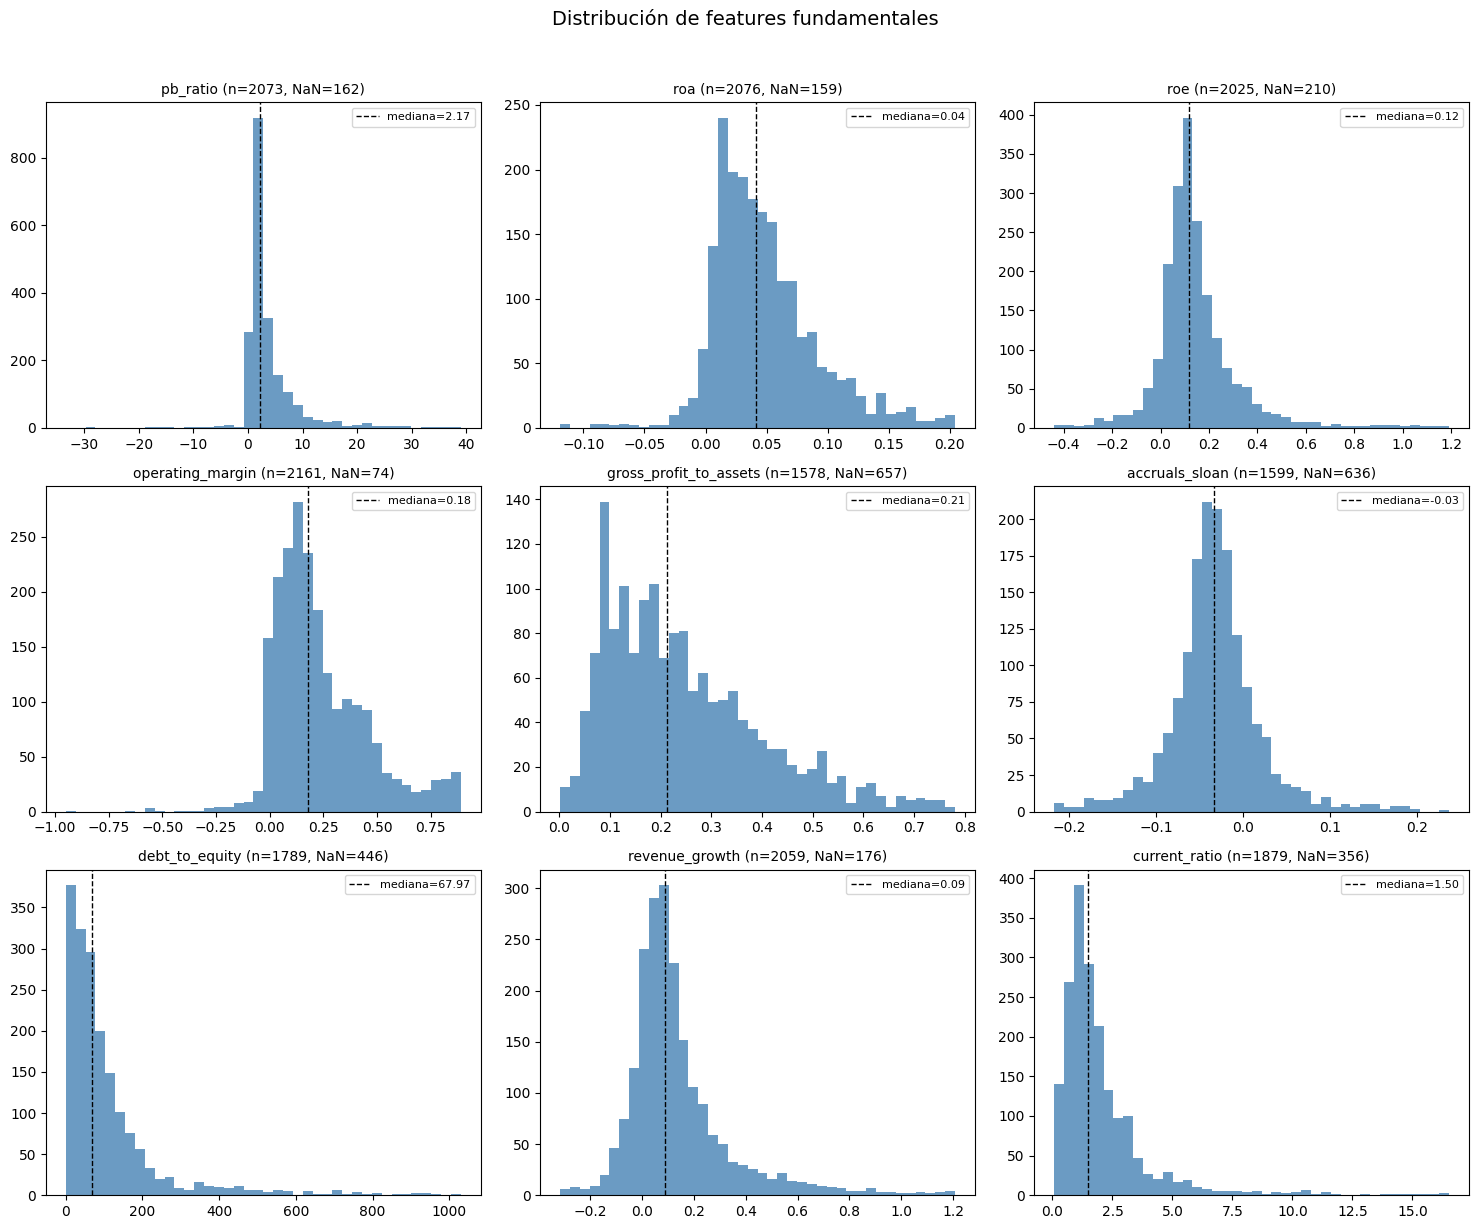

In [ ]:
fund_df, resumen_colas = convertir_colas_extremas_a_nan(fund_df, FEATURE_COLS, PERCENTIL_BAJO, PERCENTIL_ALTO)
diag_nan = diagnosticar_nan(fund_df, FEATURE_COLS)
FEATURE_COLS = excluir_features_por_nan(FEATURE_COLS, diag_nan, umbral_pct_nan=UMBRAL_EXCLUSION_NAN)
descriptivas = calcular_descriptivas(fund_df, FEATURE_COLS)
graficar_distribuciones(fund_df, FEATURE_COLS)

## Exclusión manual de features

**Entradas:** `FEATURE_COLS`.
**Salidas:** `FEATURE_COLS` (actualizado), `FEATURES_EXCLUIDOS_MANUAL`.

In [ ]:
FEATURES_EXCLUIDOS_MANUAL = []
FEATURE_COLS = [f for f in FEATURE_COLS if f not in FEATURES_EXCLUIDOS_MANUAL]
print(f"[INFO] FEATURE_COLS vigente ({len(FEATURE_COLS)}): {FEATURE_COLS}")

[INFO] FEATURE_COLS vigente (9): ['pb_ratio', 'roa', 'roe', 'operating_margin', 'gross_profit_to_assets', 'accruals_sloan', 'debt_to_equity', 'revenue_growth', 'current_ratio']


## Escalado de fundamentales

**Entradas:** `fund_df`, `FEATURE_COLS`, `METODO_ESCALADO`.
**Salidas:** `fund_df_escalado`, `scaler_fundamentales`.
**Concepto:** `RobustScaler` centra cada feature en su mediana y escala por
el rango intercuartílico -- resistente a outliers residuales, a diferencia
de `MinMaxScaler`.

In [ ]:
def escalar_features(df: pd.DataFrame, feat_cols: list, metodo: str = "robust"):
    scalers = {"zscore": StandardScaler, "minmax": MinMaxScaler, "robust": RobustScaler}
    scaler = scalers[metodo]()
    df_esc = df.copy()
    df_esc[feat_cols] = scaler.fit_transform(df[feat_cols])
    return df_esc, scaler


def normalizar_precios_df(precios_df: pd.DataFrame, col_fecha: str = "fecha") -> pd.DataFrame:
    df = precios_df.copy()
    if col_fecha in df.columns:
        df[col_fecha] = pd.to_datetime(df[col_fecha])
        return df
    if isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index()
        df = df.rename(columns={df.columns[0]: col_fecha})
        df[col_fecha] = pd.to_datetime(df[col_fecha])
        return df
    raise KeyError(f"No encuentro columna/índice de fecha. Columnas: {list(precios_df.columns)}")


def desescalar_valor(scaler, feature_cols_scaler: list, feature: str, valor_escalado: float) -> float:
    idx = feature_cols_scaler.index(feature)
    fila = np.zeros((1, len(feature_cols_scaler)))
    fila[0, idx] = valor_escalado
    return scaler.inverse_transform(fila)[0, idx]

In [ ]:
fund_df_escalado, scaler_fundamentales = escalar_features(fund_df, FEATURE_COLS, METODO_ESCALADO)
FEATURE_COLS_SCALER = list(FEATURE_COLS)

## Cálculo de beta y alpha de Jensen (`Y`)

**Entradas:** `precios_df`, `fund_df_escalado` (universo elegible), `fecha_corte`,
`VENTANA_TRAILING_DIAS`, `RF_ANNUAL`.
**Salidas:** `df_alpha` (ticker, `jensen_alpha`, `Y`, `ret_trailing`).
**Concepto:** `beta` vía regresión OLS de excesos de retorno diarios contra el
benchmark; `Y=1` si `jensen_alpha` supera la mediana transversal del universo.

In [ ]:
def compute_beta_transversal(price_panel: pd.DataFrame, eligible: list, mkt_panel: pd.DataFrame,
                              fecha_corte, ventana_dias: int, rf_anual: float = 0.0):
    fecha_ini = fecha_corte - pd.Timedelta(days=int(ventana_dias * 1.45))
    mkt_window = mkt_panel[(mkt_panel["fecha"] > fecha_ini) & (mkt_panel["fecha"] <= fecha_corte)].copy()
    mkt_window["ret_mkt"] = mkt_window["close"].pct_change()
    rf_diario = (1 + rf_anual) ** (1 / 252) - 1

    # Filtrar UNA sola vez a la ventana de fechas y al universo elegible,
    # y agrupar por ticker -- evita reescanear price_panel completo por cada ticker.
    eligible_set = set(eligible)
    precios_ventana = price_panel[
        (price_panel["fecha"] > fecha_ini) & (price_panel["fecha"] <= fecha_corte) &
        (price_panel["ticker"].isin(eligible_set))
    ][["ticker", "fecha", "close"]].sort_values(["ticker", "fecha"]).copy()
    precios_ventana["ret"] = precios_ventana.groupby("ticker")["close"].pct_change()

    merged = precios_ventana.merge(mkt_window[["fecha", "ret_mkt"]], on="fecha", how="inner").dropna(subset=["ret", "ret_mkt"])

    filas = []
    for t, g in merged.groupby("ticker", sort=False):
        if len(g) < 30:
            continue
        x = g["ret_mkt"].values - rf_diario
        y = g["ret"].values - rf_diario
        beta = np.cov(y, x)[0, 1] / np.var(x) if np.var(x) > 0 else np.nan
        filas.append({"ticker": t, "beta": beta, "n_obs": len(g)})
    return pd.DataFrame(filas), mkt_window


def compute_alpha_transversal_y(price_panel: pd.DataFrame, df_beta: pd.DataFrame, mkt_window: pd.DataFrame,
                                 fecha_corte, ventana_dias: int, rf_anual: float):
    rf_diario = (1 + rf_anual) ** (1 / 252) - 1
    ret_mkt_periodo = (mkt_window["close"].iloc[-1] / mkt_window["close"].iloc[0]) - 1
    fecha_ini = fecha_corte - pd.Timedelta(days=int(ventana_dias * 1.45))

    # Filtrar y agrupar UNA sola vez (evita reescanear price_panel por ticker).
    tickers_beta = set(df_beta["ticker"])
    precios_ventana = price_panel[
        (price_panel["fecha"] > fecha_ini) & (price_panel["fecha"] <= fecha_corte) &
        (price_panel["ticker"].isin(tickers_beta))
    ][["ticker", "fecha", "close"]].sort_values(["ticker", "fecha"])

    primero_ultimo = precios_ventana.groupby("ticker")["close"].agg(primero="first", ultimo="last", n="size")
    primero_ultimo = primero_ultimo[primero_ultimo["n"] >= 2]
    primero_ultimo["ret_trailing"] = primero_ultimo["ultimo"] / primero_ultimo["primero"] - 1

    df_alpha = df_beta.merge(primero_ultimo[["ret_trailing"]], on="ticker", how="inner")
    df_alpha["jensen_alpha"] = ((df_alpha["ret_trailing"] - rf_diario * ventana_dias) -
                                 df_alpha["beta"] * (ret_mkt_periodo - rf_diario * ventana_dias))
    df_alpha["Y"] = (df_alpha["jensen_alpha"] > df_alpha["jensen_alpha"].median()).astype(int)
    df_alpha = df_alpha[["ticker", "beta", "ret_trailing", "jensen_alpha", "Y"]]
    print(f"[INFO] alpha de Jensen calculado para {len(df_alpha)} tickers")
    print(f"[INFO] Balance: {df_alpha['Y'].mean():.1%} Y=1 ({df_alpha['Y'].sum()} de {len(df_alpha)})")
    return df_alpha


def graficar_alpha(df_alpha: pd.DataFrame):
    mediana = df_alpha["jensen_alpha"].median()
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(df_alpha.loc[df_alpha["Y"] == 0, "jensen_alpha"], bins=40, alpha=0.6, label="Y=0", color="tab:red")
    ax.hist(df_alpha.loc[df_alpha["Y"] == 1, "jensen_alpha"], bins=40, alpha=0.6, label="Y=1", color="tab:blue")
    ax.axvline(mediana, color="black", linestyle="--", linewidth=1.5, label=f"mediana={mediana:.4f}")
    ax.set_xlabel("Alpha de Jensen (trailing)")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Distribución de alpha de Jensen (n={len(df_alpha)})")
    ax.legend()
    plt.tight_layout()
    plt.show()

[INFO] alpha de Jensen calculado para 2235 tickers
[INFO] Balance: 50.0% Y=1 (1117 de 2235)


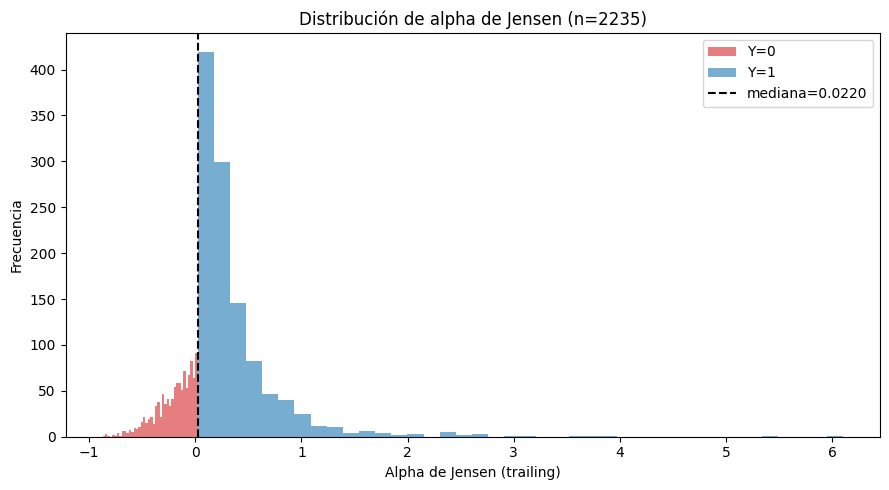

In [ ]:
eligible = fund_df_escalado["ticker"].tolist()
mkt_panel = precios_df[precios_df["ticker"] == "SPY"][["fecha", "close"]].sort_values("fecha")

df_beta, mkt_window = compute_beta_transversal(precios_df, eligible, mkt_panel, fecha_corte,
                                                VENTANA_TRAILING_DIAS, RF_ANNUAL)
df_alpha = compute_alpha_transversal_y(precios_df, df_beta, mkt_window, fecha_corte,
                                       VENTANA_TRAILING_DIAS, RF_ANNUAL)
graficar_alpha(df_alpha)

## Armado de la matriz de features

**Entradas:** `df_alpha`, `fund_df_escalado`, `FEATURE_COLS`.
**Salidas:** `df_matrix` (ticker, `Y`, fundamentales escalados, `sector`), `feature_medians`.
**Concepto:** imputación de NaN residual por la mediana de cada columna ya escalada.

In [ ]:
def assemble_feature_matrix(df_alpha: pd.DataFrame, fund_df_escalado: pd.DataFrame, feature_cols: list):
    df = pd.merge(df_alpha[["ticker", "ret_trailing", "Y"]], fund_df_escalado, on="ticker", how="inner")
    feature_medians = {}
    for col in feature_cols:
        mediana = df[col].median()
        feature_medians[col] = mediana
        df[col] = df[col].fillna(mediana)
    print(f"[INFO] df_matrix armado: {len(df)} tickers, {len(feature_cols)} features")
    return df, feature_medians

In [ ]:
df_matrix, feature_medians = assemble_feature_matrix(df_alpha, fund_df_escalado, FEATURE_COLS)
if "sector" not in df_matrix.columns and "sector" in fund_df.columns:
    df_matrix = df_matrix.merge(fund_df[["ticker", "sector"]], on="ticker", how="left")

[INFO] df_matrix armado: 2235 tickers, 9 features


## Análisis exploratorio (EDA)

**Entradas:** `df_matrix`, `FEATURE_COLS`, `UNIVERSE_TAG`.
**Salidas:** `reporte_pca.csv`, `eda_scatter_matrix.png`, `lista_exclusion_features.csv`
(en `OUTPUT_ROOT/UNIVERSE_TAG`); `reporte_diagnostico_global` (DataFrame en memoria).
**Concepto:** PCA para varianza explicada; matriz de dispersión por pares;
AUC univariado + importancia de árbol global como diagnóstico combinado por feature.

In [ ]:
def run_pca_exploratorio(df: pd.DataFrame, feat_cols: list, universe: str):
    out_dir = OUTPUT_ROOT / universe
    out_dir.mkdir(parents=True, exist_ok=True)
    pca = PCA(n_components=min(len(feat_cols), 10), random_state=42)
    scores = pca.fit_transform(df[feat_cols].values)
    varianza = pca.explained_variance_ratio_

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(range(1, len(varianza) + 1), varianza, color="steelblue")
    ax.plot(range(1, len(varianza) + 1), np.cumsum(varianza), color="black", marker="o")
    ax.set_xlabel("Componente"); ax.set_ylabel("Varianza explicada")
    ax.set_title("PCA -- varianza explicada")
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(8, 6))
    colores = np.where(df["Y"].values == 1, "steelblue", "indianred") if "Y" in df.columns else "steelblue"
    ax2.scatter(scores[:, 0], scores[:, 1], s=8, alpha=0.4, c=colores)
    ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
    ax2.set_title("PCA -- proyección 2D")
    plt.tight_layout()
    plt.show()

    loadings = pd.DataFrame(pca.components_.T, index=feat_cols,
                             columns=[f"PC{i+1}" for i in range(len(varianza))])
    loadings.to_csv(out_dir / "pca_loadings.csv")
    print(f"[PCA] Varianza acumulada k=2: {np.cumsum(varianza)[1]:.3f}")
    return pca, loadings


def run_eda_pairwise_scatter(df: pd.DataFrame, feat_cols: list, universe: str,
                              color_by_y: bool = True, max_points: int = 2500,
                              nombre_archivo: str = "eda_scatter_matrix.png"):
    out_dir = OUTPUT_ROOT / universe
    out_dir.mkdir(parents=True, exist_ok=True)
    n = len(feat_cols)
    rng = np.random.RandomState(42)
    sample = df.iloc[rng.choice(len(df), size=max_points, replace=False)] if len(df) > max_points else df
    colores = np.where(sample["Y"].values == 1, "steelblue", "indianred") if (color_by_y and "Y" in sample.columns) else "steelblue"

    fig, axes = plt.subplots(n, n, figsize=(2.0 * n, 2.0 * n))
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if j > i:
                ax.axis("off"); continue
            if i == j:
                ax.hist(sample[feat_cols[i]].dropna(), bins=25, color="gray")
            else:
                ax.scatter(sample[feat_cols[j]], sample[feat_cols[i]], s=3, alpha=0.25, c=colores, linewidths=0)
            if i == n - 1: ax.set_xlabel(feat_cols[j], fontsize=7, rotation=45, ha="right")
            else: ax.set_xticklabels([])
            if j == 0: ax.set_ylabel(feat_cols[i], fontsize=7, rotation=0, ha="right", va="center")
            else: ax.set_yticklabels([])
            ax.tick_params(labelsize=5)
    fig.suptitle(f"{universe.upper()} -- matriz de dispersión", fontsize=13, y=1.005)
    plt.tight_layout()
    plt.savefig(out_dir / nombre_archivo, dpi=110, bbox_inches="tight")
    plt.show()


def evaluar_importancia_arbol(X, y, feature_cols, max_depth=3, min_samples_leaf=20):
    tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
    tree.fit(X, y)
    imp = pd.DataFrame({"feature": feature_cols, "importance": tree.feature_importances_}).sort_values(
        "importance", ascending=False)
    print("[INFO] Importancia de variables (árbol de clasificación):")
    print(imp[imp["importance"] > 0].to_string(index=False))
    print("\n[INFO] Estructura del árbol:")
    print(export_text(tree, feature_names=feature_cols, max_depth=3))
    return imp, tree


def run_global_feature_diagnostic(df: pd.DataFrame, feat_cols: list, universe: str) -> pd.DataFrame:
    out_dir = OUTPUT_ROOT / universe
    out_dir.mkdir(parents=True, exist_ok=True)
    X, y = df[feat_cols], df["Y"]
    auc_por_feature = {f: roc_auc_score(y, X[f]) for f in feat_cols}
    imp, _ = evaluar_importancia_arbol(X.values, y.values, feat_cols)
    imp_map = dict(zip(imp["feature"], imp["importance"]))

    filas = []
    for f in feat_cols:
        auc = auc_por_feature[f]
        tree_imp = imp_map.get(f, 0.0)
        auc_fuerte = abs(auc - 0.5) > 0.05
        if auc_fuerte and tree_imp > 0: veredicto = "mantener (senal en ambas metricas)"
        elif not auc_fuerte and tree_imp == 0: veredicto = "excluir (debil en ambas metricas)"
        else: veredicto = "ambiguo (revisar manualmente antes de excluir)"
        filas.append({"feature": f, "AUC_pooled": round(auc, 4), "AUC_avg_periodo": round(auc, 4),
                       "tree_importance": tree_imp, "veredicto": veredicto})
    reporte = pd.DataFrame(filas).sort_values("AUC_pooled", ascending=False).reset_index(drop=True)
    reporte.to_csv(out_dir / "lista_exclusion_features.csv", index=False)
    print(reporte.to_string(index=False))
    return reporte

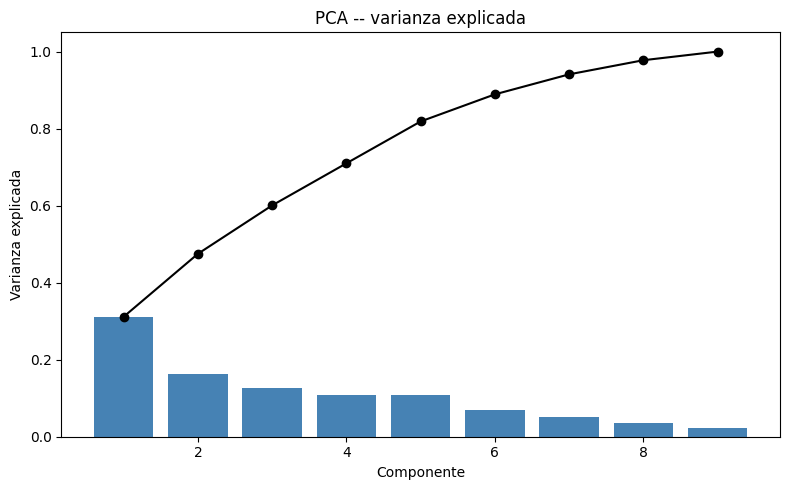

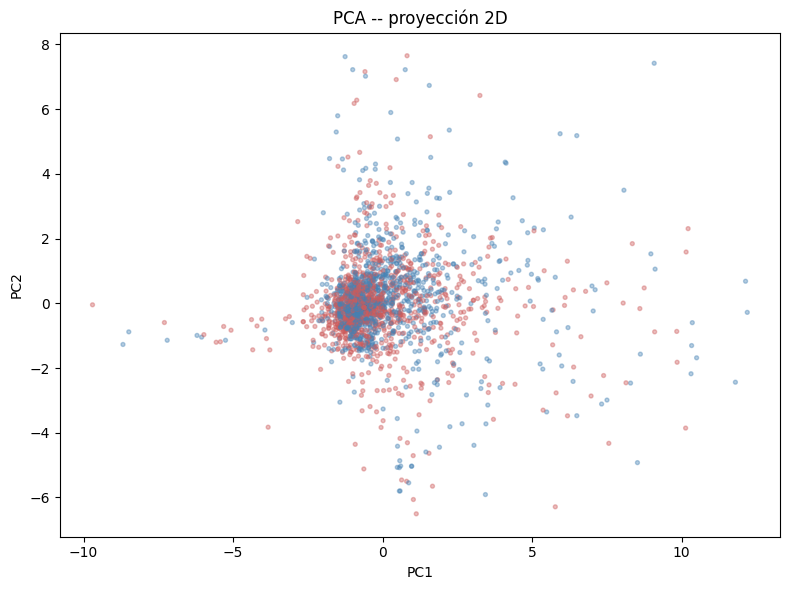

[PCA] Varianza acumulada k=2: 0.475


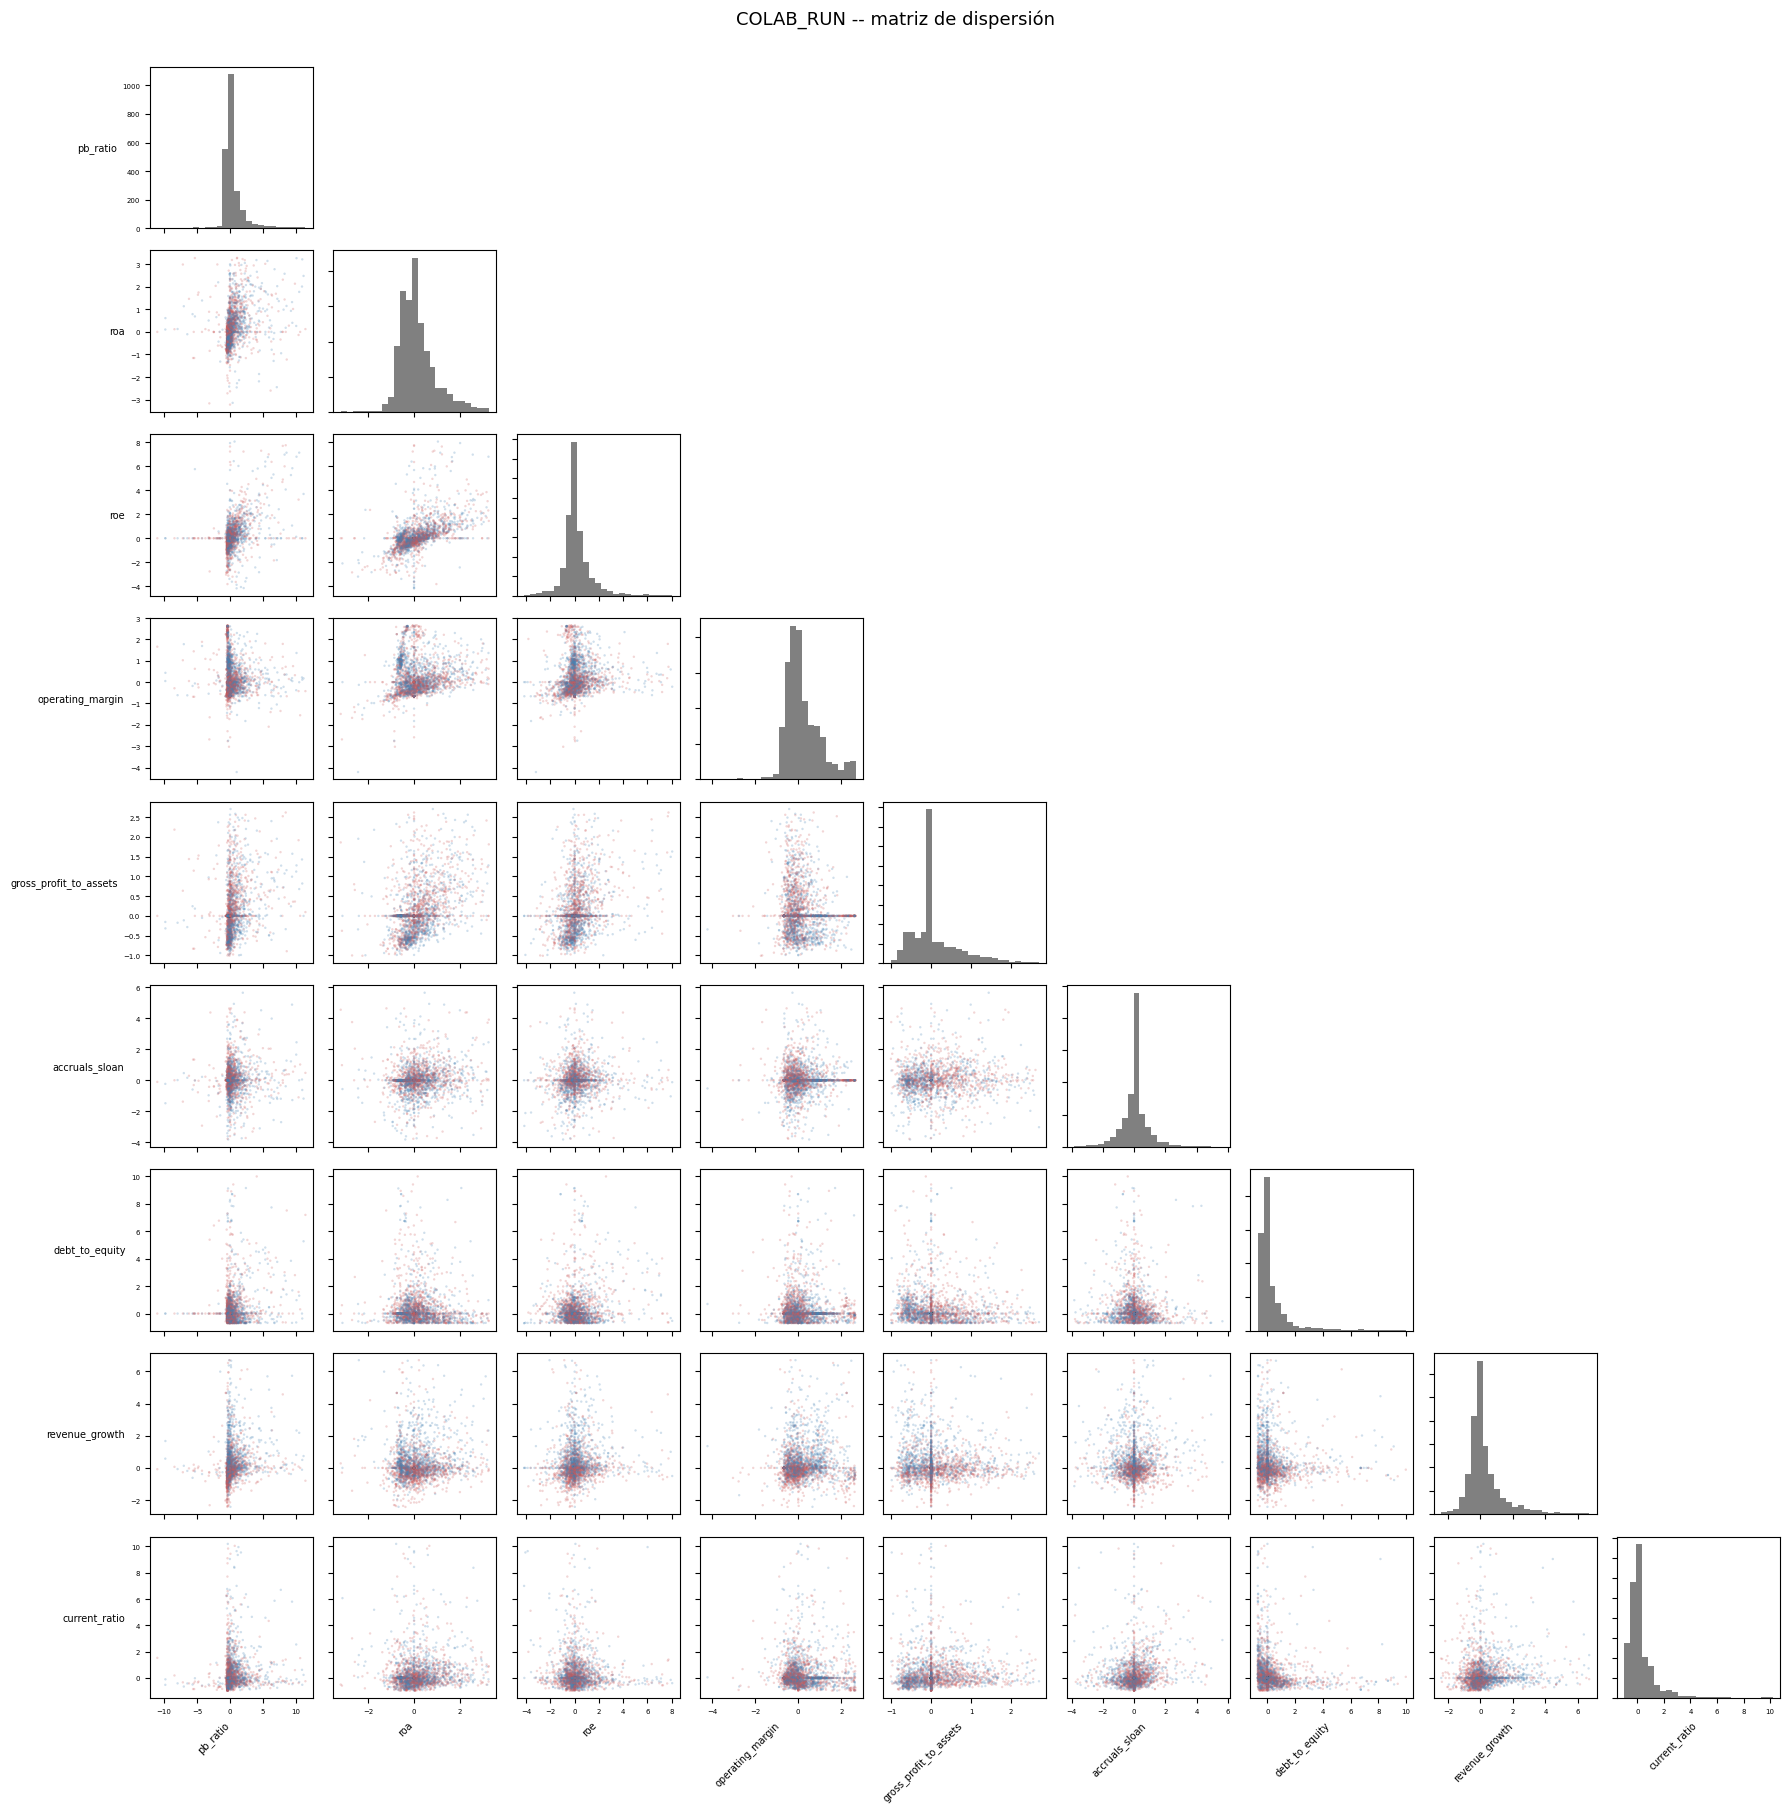

[INFO] Importancia de variables (árbol de clasificación):
               feature  importance
        revenue_growth    0.470328
              pb_ratio    0.215772
                   roa    0.152165
gross_profit_to_assets    0.119760
                   roe    0.041975

[INFO] Estructura del árbol:
|--- revenue_growth <= 0.06
|   |--- pb_ratio <= -0.36
|   |   |--- roe <= 0.15
|   |   |   |--- class: 0
|   |   |--- roe >  0.15
|   |   |   |--- class: 1
|   |--- pb_ratio >  -0.36
|   |   |--- roa <= -0.15
|   |   |   |--- class: 1
|   |   |--- roa >  -0.15
|   |   |   |--- class: 0
|--- revenue_growth >  0.06
|   |--- gross_profit_to_assets <= 0.06
|   |   |--- pb_ratio <= -0.38
|   |   |   |--- class: 0
|   |   |--- pb_ratio >  -0.38
|   |   |   |--- class: 1
|   |--- gross_profit_to_assets >  0.06
|   |   |--- revenue_growth <= 0.91
|   |   |   |--- class: 0
|   |   |--- revenue_growth >  0.91
|   |   |   |--- class: 1

               feature  AUC_pooled  AUC_avg_periodo  tree_importanc

In [ ]:
pca, pca_loadings = run_pca_exploratorio(df_matrix, FEATURE_COLS, UNIVERSE_TAG)
run_eda_pairwise_scatter(df_matrix, FEATURE_COLS, UNIVERSE_TAG)
reporte_diagnostico_global = run_global_feature_diagnostic(df_matrix, FEATURE_COLS, UNIVERSE_TAG)

## Segmentación -- K-Medoids

**Entradas:** matriz de features, número de clusters `K`, `metric` (`euclidean`,
`manhattan` o `mahalanobis`).
**Salidas:** `labels_`, `cluster_centers_`, `medoid_indices_`.
**Concepto:** algoritmo PAM simplificado -- inicializa medoides al azar, asigna
cada punto al medoide más cercano según `metric`, y actualiza cada medoide al
punto de su cluster que minimiza la distancia intra-cluster total. Con
`metric="mahalanobis"`, la distancia usa la inversa de la matriz de covarianza
del conjunto (`VI`), corrigiendo por correlación entre features.

In [ ]:
class KMedoidsManual:
    def __init__(self, n_clusters=5, metric="euclidean", max_iter=100, random_state=42):
        self.n_clusters = n_clusters
        self.metric = metric
        self.max_iter = max_iter
        self.random_state = random_state

    def _distancias(self, A, B):
        if self.metric == "mahalanobis":
            return pairwise_distances(A, B, metric="mahalanobis", VI=self._VI)
        return pairwise_distances(A, B, metric=self.metric)

    def fit(self, X):
        X = np.asarray(X)
        rng = np.random.default_rng(self.random_state)
        n = X.shape[0]
        if self.metric == "mahalanobis":
            cov = np.cov(X, rowvar=False) + np.eye(X.shape[1]) * 1e-6
            self._VI = np.linalg.inv(cov)

        medoides_idx = rng.choice(n, self.n_clusters, replace=False)
        for _ in range(self.max_iter):
            D = self._distancias(X, X[medoides_idx])
            labels = D.argmin(axis=1)
            nuevos = medoides_idx.copy()
            for k in range(self.n_clusters):
                miembros = np.where(labels == k)[0]
                if len(miembros) == 0:
                    continue
                D_intra = self._distancias(X[miembros], X[miembros])
                nuevos[k] = miembros[D_intra.sum(axis=1).argmin()]
            if np.array_equal(nuevos, medoides_idx):
                break
            medoides_idx = nuevos

        self.medoid_indices_ = medoides_idx
        self.cluster_centers_ = X[medoides_idx]
        self.labels_ = labels
        return self

    def predict(self, X):
        D = self._distancias(np.asarray(X), self.cluster_centers_)
        return D.argmin(axis=1)


def assign_static_clusters(df: pd.DataFrame, feat_cols: list, n_clusters: int,
                            method: str = "kmedoids", universe: str = "", metric: str = "mahalanobis"):
    X = df[feat_cols].values
    if method == "kmedoids":
        modelo = KMedoidsManual(n_clusters=n_clusters, metric=metric, random_state=42).fit(X)
        labels = modelo.labels_
    elif method == "kmeans":
        modelo = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(X)
        labels = modelo.labels_
    else:
        raise ValueError("method debe ser 'kmedoids' o 'kmeans'")

    df_out = df.copy()
    df_out["cluster"] = labels
    print(f"[INFO] Clusters asignados ({method}, {metric}, K={n_clusters}) sobre {len(df_out)} tickers:")
    print(df_out["cluster"].value_counts().sort_index().to_string())
    return df_out, None, modelo

## Modelo supervisado por cluster

**Entradas:** `df_cluster` (subconjunto de un cluster), `feature_cols`, `precios_df`,
`fund_df`, `n_splits`, `min_n`.
**Salidas:** diccionario con `ranking`, `auc_oof`, `selected_features`,
`modelo_full`, `scaler_full`, `n`, `importancia`.
**Concepto:** Information Value por feature (`scorecardpy`) para seleccionar
`selected`; validación cruzada estratificada con `LogisticRegressionCV`
(Elastic Net, selección anidada de `C`); predicciones out-of-fold.

In [ ]:
def evaluate_information_value(df: pd.DataFrame, feature_cols: list, output_dir: Path) -> pd.DataFrame:
    try:
        iv_df = sc.iv(df[feature_cols + ["Y"]], y="Y")
        iv_df = iv_df.rename(columns={"info_value": "info_value", "variable": "variable"})
    except Exception:
        iv_df = pd.DataFrame({"variable": feature_cols, "info_value": [0.0] * len(feature_cols)})
    def interpretar(v):
        if v >= 0.3: return "fuerte"
        if v >= 0.1: return "medio"
        if v >= 0.02: return "débil"
        return "sin poder"
    iv_df["interpretacion"] = iv_df["info_value"].apply(interpretar)
    iv_df = iv_df.sort_values("info_value", ascending=False)
    print("[INFO] Calculando Information Value (IV)...")
    print(iv_df.to_string(index=False))
    return iv_df


def get_last_price(precios_df: pd.DataFrame, ticker: str):
    p = precios_df[precios_df["ticker"] == ticker].sort_values("fecha")
    if len(p) == 0:
        return None, None
    return p["close"].iloc[-1], p["fecha"].iloc[-1]


def construir_lookup_ultimo_precio(precios_df: pd.DataFrame, col_fecha: str = "fecha",
                                    col_ticker: str = "ticker", col_precio: str = "close") -> pd.DataFrame:
    """Último precio y fecha por ticker, calculado UNA sola vez sobre todo
    precios_df -- evita reescanear el DataFrame completo por cada ticker
    dentro de train_model_kfold, que se llama muchas veces por cada K del barrido."""
    df = normalizar_precios_df(precios_df, col_fecha).sort_values(col_fecha)
    return df.groupby(col_ticker).agg(
        last_close=(col_precio, "last"), last_close_date=(col_fecha, "last")
    ).reset_index()


def train_model_kfold(df_cluster: pd.DataFrame, feature_cols: list, output_dir: Path,
                       precios_lookup: pd.DataFrame, fund_df: pd.DataFrame,
                       n_splits: int = 5, min_n: int = 50):
    n = len(df_cluster)
    if n < min_n:
        print(f"[WARN] n={n} < min_n={min_n} -- se omite el entrenamiento de este cluster.")
        return None

    print(f"\n[INFO] n={n} tickers -- {n_splits}-Fold estratificado")
    iv_df = evaluate_information_value(df_cluster, feature_cols, output_dir)
    selected = iv_df[iv_df["info_value"] >= IV_THRESHOLD]["variable"].tolist() or feature_cols

    X = df_cluster[selected].copy()
    for col in selected:
        if X[col].isna().any():
            X[col] = X[col].fillna(X[col].median())
    y = df_cluster["Y"].values
    tickers = df_cluster["ticker"].values

    imp_df, _ = evaluar_importancia_arbol(X.values, pd.Series(y).values, selected)

    skf_splits = []
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_p_hat = np.full(n, np.nan)
    oof_score_lineal = np.full(n, np.nan)

    for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
        scaler_fold = RobustScaler()
        X_tr_sc = scaler_fold.fit_transform(X.iloc[tr_idx])
        X_te_sc = scaler_fold.transform(X.iloc[te_idx])
        modelo_fold = LogisticRegressionCV(
            Cs=C_GRID, cv=3, penalty="elasticnet", solver="saga", l1_ratios=[L1_RATIO],
            max_iter=10000, tol=1e-3, class_weight="balanced", scoring="roc_auc", random_state=42,
        )
        modelo_fold.fit(X_tr_sc, y[tr_idx])
        oof_p_hat[te_idx] = modelo_fold.predict_proba(X_te_sc)[:, 1]
        oof_score_lineal[te_idx] = X_te_sc @ modelo_fold.coef_[0] + modelo_fold.intercept_[0]
        print(f"  Fold {fold_i+1}/{n_splits}: n_test={len(te_idx)}, C elegido={modelo_fold.C_[0]:.4f}")

    auc_oof = roc_auc_score(y, oof_p_hat)
    print(f"\n[INFO] AUC out-of-fold: {auc_oof:.4f}")

    y_pred_oof = (oof_p_hat >= 0.5).astype(int)
    print("\nMatriz de confusión (out-of-fold, umbral=0.5):")
    print(confusion_matrix(y, y_pred_oof))
    print("\nReporte de clasificación (out-of-fold):")
    print(classification_report(y, y_pred_oof, digits=4, zero_division=0))

    scaler_full = RobustScaler()
    X_full_sc = scaler_full.fit_transform(X)
    modelo_full = LogisticRegressionCV(
        Cs=C_GRID, cv=3, penalty="elasticnet", solver="saga", l1_ratios=[L1_RATIO],
        max_iter=10000, tol=1e-3, class_weight="balanced", scoring="roc_auc", random_state=42,
    )
    modelo_full.fit(X_full_sc, y)

    ranking = pd.DataFrame({"ticker": tickers, "Y": y, "p_hat": oof_p_hat, "score_lineal": oof_score_lineal})
    for col in selected:
        ranking[col] = df_cluster[col].values
    if "sector" in df_cluster.columns:
        ranking["sector"] = df_cluster["sector"].values
    ranking = ranking.sort_values("p_hat", ascending=False).reset_index(drop=True)
    ranking["rank"] = ranking.index + 1

    def _coherencia(row):
        n_c, n_t = 0, 0
        for feat in selected:
            expected = EXPECTED_SIGNS.get(feat)
            if expected is None:
                continue
            val = row[feat]
            if pd.notna(val) and val != 0:
                n_t += 1
                if (val > 0 and expected > 0) or (val < 0 and expected < 0):
                    n_c += 1
        return round(n_c / n_t, 2) if n_t > 0 else np.nan
    ranking["coherencia"] = ranking.apply(_coherencia, axis=1)

    ranking = ranking.merge(precios_lookup[["ticker", "last_close", "last_close_date"]], on="ticker", how="left")

    print("[INFO] Top 10 (por p_hat out-of-fold):")
    print(ranking.head(10)[["rank", "ticker", "p_hat", "score_lineal", "coherencia"]].to_string(index=False))

    return {"ranking": ranking, "auc_oof": auc_oof, "selected_features": selected,
            "modelo_full": modelo_full, "scaler_full": scaler_full, "n": n, "importancia": imp_df}


def resumen_y_confusion_consolidada(resultados_por_cluster: dict, ranking_final: pd.DataFrame):
    resumen = pd.DataFrame([{"cluster": c, "n": r["n"], "auc_oof": round(r["auc_oof"], 4)}
                            for c, r in resultados_por_cluster.items()]).sort_values("cluster")
    print("[INFO] Resumen por cluster:")
    print(resumen.to_string(index=False))
    y_pred_consolidado = (ranking_final["p_hat"] >= 0.5).astype(int)
    print(f"\nAUC consolidado: {roc_auc_score(ranking_final['Y'], ranking_final['p_hat']):.4f}")
    print("Matriz de confusión consolidada:")
    print(confusion_matrix(ranking_final["Y"], y_pred_consolidado))
    return resumen


def resumen_importancia_por_cluster(resultados_por_cluster: dict) -> pd.DataFrame:
    filas = []
    for c, r in resultados_por_cluster.items():
        imp_df = r.get("importancia")
        if imp_df is None or imp_df.empty:
            continue
        for _, row in imp_df.iterrows():
            filas.append({"cluster": c, "feature": row["feature"], "importance": row["importance"]})
    if not filas:
        return pd.DataFrame()
    tabla = pd.DataFrame(filas).pivot(index="feature", columns="cluster", values="importance").fillna(0.0)
    tabla = tabla.loc[tabla.sum(axis=1).sort_values(ascending=False).index]
    print("[INFO] Importancia de árbol por feature y cluster:")
    print(tabla.round(3).to_string())
    return tabla

## Significancia estadística

**Entradas:** `pooled_df` (ticker, `y_true`, `p_hat`, `cluster`), `out_dir`.
**Salidas:** `test_significancia_auc_clusters.csv`, `test_pareado_clusters.csv`.
**Concepto:** test de DeLong para AUC vs. 0.50 por cluster, bootstrap (5000
iteraciones) para intervalo de confianza, potencia post-hoc, y comparaciones
pareadas entre clusters con corrección de Bonferroni.

In [ ]:
def _delong_auc_var(y_true, y_score):
    order = np.argsort(-y_score)
    y_true, y_score = y_true[order], y_score[order]
    pos, neg = y_score[y_true == 1], y_score[y_true == 0]
    n_pos, n_neg = len(pos), len(neg)
    if n_pos == 0 or n_neg == 0:
        return np.nan, np.nan
    auc = roc_auc_score(y_true, y_score)
    v10 = np.array([np.mean(pos[i] > neg) + 0.5 * np.mean(pos[i] == neg) for i in range(n_pos)])
    v01 = np.array([np.mean(p > neg[j]) + 0.5 * np.mean(p == neg[j]) for j in range(n_neg) for p in [pos]][:0])
    v01 = np.array([np.mean(pos > neg[j]) + 0.5 * np.mean(pos == neg[j]) for j in range(n_neg)])
    s10 = np.var(v10, ddof=1) / n_pos if n_pos > 1 else 0
    s01 = np.var(v01, ddof=1) / n_neg if n_neg > 1 else 0
    return auc, s10 + s01


def evaluar_significancia_auc_clusters(pooled_df: pd.DataFrame, out_dir: Path,
                                        alpha: float = 0.05, n_boot: int = 5000, seed: int = 42):
    out_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(seed)
    filas = []
    boot_por_cluster = {}
    for c, g in pooled_df.groupby("cluster"):
        y_true, y_score = g["y_true"].values, g["p_hat"].values
        n_pos, n_neg = int(y_true.sum()), int((1 - y_true).sum())
        auc, var_auc = _delong_auc_var(y_true, y_score)
        se = np.sqrt(var_auc) if var_auc == var_auc else np.nan
        z = (auc - 0.5) / se if se and se > 0 else np.nan
        p = 2 * (1 - stats.norm.cdf(abs(z))) if z == z else np.nan

        boots = []
        idx = np.arange(len(g))
        for _ in range(n_boot):
            s = rng.choice(idx, size=len(idx), replace=True)
            yb, sb = y_true[s], y_score[s]
            if len(np.unique(yb)) < 2:
                continue
            boots.append(roc_auc_score(yb, sb))
        boots = np.array(boots)
        boot_por_cluster[c] = boots
        ic_low, ic_high = (np.percentile(boots, 2.5), np.percentile(boots, 97.5)) if len(boots) else (np.nan, np.nan)

        effect = abs(auc - 0.5) if auc == auc else 0
        potencia = 1 - stats.norm.cdf(1.96 - effect / se) if se and se > 0 else np.nan
        mde = 1.96 * se + 0.8416 * se if se and se > 0 else np.nan

        filas.append({"cluster": c, "n_test": len(g), "n_pos": n_pos, "n_neg": n_neg,
                       "auc_delong": round(auc, 4), "se_delong": round(se, 4) if se == se else np.nan,
                       "z_vs_0.50": round(z, 3) if z == z else np.nan, "p_valor_vs_0.50": round(p, 4) if p == p else np.nan,
                       "significativo_vs_0.50_alpha0.05": bool(p < alpha) if p == p else False,
                       "boot_auc_media": round(np.mean(boots), 4) if len(boots) else np.nan,
                       "boot_ic95_low": round(ic_low, 4), "boot_ic95_high": round(ic_high, 4),
                       "boot_ic_incluye_0.50": bool(ic_low <= 0.5 <= ic_high) if ic_low == ic_low else True,
                       "potencia_posthoc_al_auc_observado": round(potencia, 4) if potencia == potencia else np.nan,
                       "mde_auc_80pct_potencia_alpha0.05": round(0.5 + mde, 4) if mde == mde else np.nan})
    sig_res_df = pd.DataFrame(filas)

    clusters = sig_res_df["cluster"].tolist()
    pares = []
    n_comp = max(len(clusters) * (len(clusters) - 1) // 2, 1)
    alpha_bonf = alpha / n_comp
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            ci, cj = clusters[i], clusters[j]
            auc_i = sig_res_df.loc[sig_res_df["cluster"] == ci, "auc_delong"].iloc[0]
            auc_j = sig_res_df.loc[sig_res_df["cluster"] == cj, "auc_delong"].iloc[0]
            bi, bj = boot_por_cluster.get(ci, np.array([])), boot_por_cluster.get(cj, np.array([]))
            n_min = min(len(bi), len(bj))
            if n_min > 10:
                diff = bi[:n_min] - bj[:n_min]
                se_diff = np.std(diff, ddof=1)
                z = (auc_i - auc_j) / se_diff if se_diff > 0 else np.nan
                p_val = 2 * (1 - stats.norm.cdf(abs(z))) if z == z else np.nan
            else:
                z, p_val = np.nan, np.nan
            pares.append({"cluster_i": ci, "cluster_j": cj, "auc_i": auc_i, "auc_j": auc_j,
                          "diff_auc": round(auc_i - auc_j, 4), "z": round(z, 3) if z == z else np.nan,
                          "p_valor": round(p_val, 4) if p_val == p_val else np.nan,
                          "alpha_bonferroni": round(alpha_bonf, 4),
                          "significativo_bonferroni": bool(p_val < alpha_bonf) if p_val == p_val else False})
    pares_df = pd.DataFrame(pares, columns=["cluster_i", "cluster_j", "auc_i", "auc_j", "diff_auc",
                                             "z", "p_valor", "alpha_bonferroni", "significativo_bonferroni"])

    print(sig_res_df.to_string(index=False))
    print(f"\n[Comparaciones pareadas -- umbral Bonferroni={alpha_bonf:.4f} para {n_comp} comparaciones]")
    print(pares_df.to_string(index=False))
    sig_res_df.to_csv(out_dir / "test_significancia_auc_clusters.csv", index=False)
    pares_df.to_csv(out_dir / "test_pareado_clusters.csv", index=False)
    return sig_res_df, pares_df

## Calibración Platt

**Entradas:** `pooled_df`, `out_dir`.
**Salidas:** `calibracion_platt_por_cluster.csv`, `calibracion_resumen.csv`.
**Concepto:** regresión logística 1D (`p_hat_calibrado = sigmoid(A*score + B)`)
ajustada por cluster sobre las mismas predicciones out-of-fold.

In [ ]:
def calibrar_platt_por_cluster(pooled_df: pd.DataFrame, out_dir: Path) -> dict:
    out_dir.mkdir(parents=True, exist_ok=True)
    calibradores = {}
    filas = []
    for c, g in pooled_df.groupby("cluster"):
        y, p = g["y_true"].values, g["p_hat"].values
        p = np.clip(p, 1e-6, 1 - 1e-6)
        logit_p = np.log(p / (1 - p)).reshape(-1, 1)
        if len(np.unique(y)) < 2:
            calibradores[c] = (1.0, 0.0)
            filas.append({"cluster": c, "n_val": len(g), "A_pendiente": 1.0, "B_intercepto": 0.0, "calibrado": False})
            continue
        modelo = LogisticRegressionCV(Cs=[1e6], cv=2, max_iter=2000).fit(logit_p, y)
        A, B = modelo.coef_[0][0], modelo.intercept_[0]
        calibradores[c] = (A, B)
        filas.append({"cluster": c, "n_val": len(g), "A_pendiente": round(A, 4),
                      "B_intercepto": round(B, 4), "calibrado": True})
    tabla = pd.DataFrame(filas)
    print(tabla.to_string(index=False))
    tabla.to_csv(out_dir / "calibracion_platt_por_cluster.csv", index=False)
    return calibradores


def aplicar_calibracion_platt(df: pd.DataFrame, calibradores: dict) -> pd.Series:
    def _cal(row):
        A, B = calibradores.get(row["cluster"], (1.0, 0.0))
        p = np.clip(row["p_hat"], 1e-6, 1 - 1e-6)
        logit_p = np.log(p / (1 - p))
        return 1 / (1 + np.exp(-(A * logit_p + B)))
    return df.apply(_cal, axis=1)


def evaluar_calibracion(pooled_df: pd.DataFrame, out_dir: Path):
    y = pooled_df["y_true"].values
    auc_antes = roc_auc_score(y, pooled_df["p_hat"])
    auc_despues = roc_auc_score(y, pooled_df["p_hat_calibrado"])
    brier_antes = np.mean((pooled_df["p_hat"] - y) ** 2)
    brier_despues = np.mean((pooled_df["p_hat_calibrado"] - y) ** 2)
    resumen = pd.DataFrame([{"n_test": len(pooled_df), "auc_pooled_antes": round(auc_antes, 4),
                             "auc_pooled_despues": round(auc_despues, 4), "brier_pooled_antes": round(brier_antes, 4),
                             "brier_pooled_despues": round(brier_despues, 4),
                             "mejora_brier": round(brier_antes - brier_despues, 4)}])
    print(resumen.to_string(index=False))
    resumen.to_csv(out_dir / "calibracion_resumen.csv", index=False)
    return resumen

## Armado del pool de candidatos

**Entradas:** `ranking_df`, `n_total`, `clusters_significativos`, `sig_res_df` (opcional),
`coherencia_por_cluster_df` (opcional).
**Salidas:** `pool_candidatos.csv`.
**Concepto:** cupo por cluster proporcional a `edge x potencia` (`edge = AUC - 0.5`);
dentro de cada cluster, orden por `p_hat_calibrado` si hay diferenciación interna
(`std_calibrada` por encima de un umbral), o diversificación por sector si no la hay.

In [ ]:
def _asignar_cupos_por_edge(clusters_incluidos: pd.DataFrame, n_total: int,
                             cluster_col: str = "cluster", edge_col: str = "edge") -> dict:
    pesos = clusters_incluidos.set_index(cluster_col)[edge_col].clip(lower=1e-6)
    proporciones = pesos / pesos.sum()
    cupos_float = proporciones * n_total
    cupos = cupos_float.astype(int).to_dict()
    resto = n_total - sum(cupos.values())
    residuales = (cupos_float - cupos_float.astype(int)).sort_values(ascending=False)
    for c in residuales.index[:resto]:
        cupos[c] += 1
    return cupos


def armar_pool_candidatos(ranking_df: pd.DataFrame, n_total: int,
                           clusters_significativos: list = None,
                           p_hat_col: str = "p_hat_calibrado", cluster_col: str = "cluster",
                           sector_col: str = "sector", edge_col: str = "cluster_auc_test",
                           std_umbral_diferenciacion: float = 0.005, seed: int = 42,
                           sig_res_df: pd.DataFrame = None,
                           coherencia_por_cluster_df: pd.DataFrame = None) -> pd.DataFrame:
    df = ranking_df if clusters_significativos is None else ranking_df[ranking_df[cluster_col].isin(clusters_significativos)]
    if len(df) == 0:
        print("[WARN] No hay tickers en los clusters significativos.")
        return pd.DataFrame()

    resumen_cluster = df.groupby(cluster_col).agg(
        media_calibrada=(p_hat_col, "mean"), std_calibrada=(p_hat_col, "std"),
        edge=(edge_col, lambda s: s.iloc[0] - 0.5), n_disponibles=(p_hat_col, "size"),
    ).reset_index()

    if sig_res_df is not None and "potencia_posthoc_al_auc_observado" in sig_res_df.columns:
        potencia_map = sig_res_df.set_index(cluster_col)["potencia_posthoc_al_auc_observado"].to_dict()
        resumen_cluster["potencia_posthoc"] = resumen_cluster[cluster_col].map(potencia_map).fillna(1.0)
    else:
        resumen_cluster["potencia_posthoc"] = 1.0
    resumen_cluster["peso"] = resumen_cluster["edge"] * resumen_cluster["potencia_posthoc"]

    if coherencia_por_cluster_df is not None and "hipotesis_confirmada_alpha0.05" in coherencia_por_cluster_df.columns:
        coh_map = coherencia_por_cluster_df.set_index(cluster_col)["hipotesis_confirmada_alpha0.05"].to_dict()
        resumen_cluster["coherencia_confirmada"] = resumen_cluster[cluster_col].map(coh_map)
    else:
        resumen_cluster["coherencia_confirmada"] = np.nan

    resumen_cluster["tiene_diferenciacion_interna"] = (
        (resumen_cluster["std_calibrada"] >= std_umbral_diferenciacion) |
        (resumen_cluster[cluster_col].isin(clusters_significativos or []))
    )
    clusters_incluidos = resumen_cluster.copy()
    cupos = _asignar_cupos_por_edge(clusters_incluidos, n_total, cluster_col, "peso")

    print(clusters_incluidos[[cluster_col, "n_disponibles", "media_calibrada", "edge", "potencia_posthoc",
                              "peso", "std_calibrada", "tiene_diferenciacion_interna", "coherencia_confirmada"]]
          .assign(cupo=lambda d: d[cluster_col].map(cupos)).to_string(index=False))

    rng = np.random.default_rng(seed)
    partes = []
    for _, fila in clusters_incluidos.iterrows():
        c, cupo = fila[cluster_col], int(cupos.get(fila[cluster_col], 0))
        if cupo <= 0:
            continue
        g = df[df[cluster_col] == c].copy()
        if fila["tiene_diferenciacion_interna"]:
            g = g.sort_values(p_hat_col, ascending=False)
        elif sector_col in g.columns:
            g = g.sample(frac=1, random_state=seed)
            g["_orden_sector"] = g.groupby(sector_col).cumcount()
            g = g.sort_values("_orden_sector")
        partes.append(g.head(cupo))

    pool = pd.concat(partes, ignore_index=True) if partes else pd.DataFrame()
    print(f"\n[OK] Pool armado: {len(pool)} candidatos "
          f"({dict(zip(clusters_incluidos[cluster_col], [int(cupos.get(c,0)) for c in clusters_incluidos[cluster_col]]))})")
    return pool

## Coherencia económica y score lineal vs. `Y`

**Entradas:** `ranking_df`, `out_dir`.
**Salidas:** `coherencia_vs_Y.csv`, `score_lineal_vs_Y.csv`, `score_lineal_vs_Y_por_cluster.csv`.
**Concepto:** test de Mann-Whitney U (unilateral y bilateral) comparando la
distribución de `coherencia`/`score_lineal` entre `Y=1` e `Y=0`.

In [ ]:
def _mannwhitney_resumen(g0, g1):
    u, p_bi = stats.mannwhitneyu(g1, g0, alternative="two-sided")
    _, p_uni = stats.mannwhitneyu(g1, g0, alternative="greater")
    rank_biserial = 1 - (2 * u) / (len(g0) * len(g1))
    t_stat, p_ttest = stats.ttest_ind(g1, g0, equal_var=False)
    return u, p_uni, p_bi, rank_biserial, t_stat, p_ttest


def evaluar_coherencia_vs_Y(ranking_df: pd.DataFrame, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    g0 = ranking_df.loc[ranking_df["Y"] == 0, "coherencia"].dropna()
    g1 = ranking_df.loc[ranking_df["Y"] == 1, "coherencia"].dropna()
    u, p_uni, p_bi, rb, t_stat, p_ttest = _mannwhitney_resumen(g0, g1)
    resumen = pd.DataFrame([{"n_Y0": len(g0), "n_Y1": len(g1), "media_coherencia_Y0": round(g0.mean(), 4),
                             "media_coherencia_Y1": round(g1.mean(), 4), "mannwhitney_U": u,
                             "p_valor_mannwhitney_unilateral_H1_Y1_mayor": round(p_uni, 5),
                             "hipotesis_confirmada_alpha0.05_unilateral": bool(p_uni < 0.05)}])
    print(resumen.to_string(index=False))
    resumen.to_csv(out_dir / "coherencia_vs_Y.csv", index=False)
    return resumen


def evaluar_coherencia_vs_Y_por_cluster(ranking_df: pd.DataFrame, out_dir: Path):
    filas = []
    for c, g in ranking_df.groupby("cluster"):
        g0, g1 = g.loc[g["Y"] == 0, "coherencia"].dropna(), g.loc[g["Y"] == 1, "coherencia"].dropna()
        if len(g0) < 5 or len(g1) < 5:
            continue
        try:
            _, p_one = stats.mannwhitneyu(g1, g0, alternative="greater")
        except ValueError:
            p_one = np.nan
        filas.append({"cluster": c, "n_Y0": len(g0), "n_Y1": len(g1), "media_coherencia_Y0": round(g0.mean(), 4),
                      "media_coherencia_Y1": round(g1.mean(), 4), "diferencia_Y1_menos_Y0": round(g1.mean() - g0.mean(), 4),
                      "p_valor_unilateral_H1_Y1_mayor": round(p_one, 5) if pd.notna(p_one) else np.nan,
                      "hipotesis_confirmada_alpha0.05": bool(p_one < 0.05) if pd.notna(p_one) else False})
    tabla = pd.DataFrame(filas)
    print(tabla.to_string(index=False))
    return tabla


def evaluar_score_lineal_vs_Y(ranking_df: pd.DataFrame, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    g0 = ranking_df.loc[ranking_df["Y"] == 0, "score_lineal"].dropna()
    g1 = ranking_df.loc[ranking_df["Y"] == 1, "score_lineal"].dropna()
    u, p_uni, p_bi, rb, t_stat, p_ttest = _mannwhitney_resumen(g0, g1)
    auc_equiv = u / (len(g0) * len(g1))
    resumen = pd.DataFrame([{"n_Y0": len(g0), "n_Y1": len(g1), "media_score_Y0": round(g0.mean(), 4),
                             "media_score_Y1": round(g1.mean(), 4), "auc_equivalente_U_n1n0": round(auc_equiv, 4),
                             "p_valor_mannwhitney_unilateral_H1_Y1_mayor": round(p_uni, 5),
                             "hipotesis_confirmada_alpha0.05_unilateral": bool(p_uni < 0.05)}])
    print(resumen.to_string(index=False))
    resumen.to_csv(out_dir / "score_lineal_vs_Y.csv", index=False)
    return resumen


def evaluar_score_lineal_vs_Y_por_cluster(ranking_df: pd.DataFrame, out_dir: Path):
    filas = []
    for c, g in ranking_df.groupby("cluster"):
        g0, g1 = g.loc[g["Y"] == 0, "score_lineal"].dropna(), g.loc[g["Y"] == 1, "score_lineal"].dropna()
        if len(g0) < 5 or len(g1) < 5:
            continue
        u, p_uni, *_ = _mannwhitney_resumen(g0, g1)
        filas.append({"cluster": c, "n_Y0": len(g0), "n_Y1": len(g1), "media_score_Y0": round(g0.mean(), 4),
                      "media_score_Y1": round(g1.mean(), 4), "auc_equivalente_U_n1n0": round(u / (len(g0) * len(g1)), 4),
                      "p_valor_mannwhitney_unilateral_H1_Y1_mayor": round(p_uni, 5),
                      "hipotesis_confirmada_alpha0.05_unilateral": bool(p_uni < 0.05)})
    tabla = pd.DataFrame(filas)
    tabla.to_csv(out_dir / "score_lineal_vs_Y_por_cluster.csv", index=False)
    print(tabla.to_string(index=False))
    return tabla

## Barrido de K

**Entradas:** `df_matrix`, `FEATURE_COLS`, `GRID_K`, `precios_df`, `fund_df`,
`cluster_method` (default `"kmedoids"`), `distance_metric` (default `"mahalanobis"`).
**Salidas:** `resultados_por_k` (dict, un resultado completo por K),
`tabla_frecuencia_k` (DataFrame, top tickers por frecuencia en el pool).
**Concepto:** repite segmentación + modelo + significancia + calibración + pool
para cada valor de `K` en la grilla, tratando `K` como una fuente de
incertidumbre a promediar en vez de un hiperparámetro único a fijar.

In [ ]:
def barrido_k(df_matrix: pd.DataFrame, feature_cols: list, grid_k: list,
              universe_tag_base: str, precios_lookup: pd.DataFrame, fund_df: pd.DataFrame,
              cluster_method: str = "kmedoids", distance_metric: str = "mahalanobis",
              n_splits_cv: int = 5, min_n_cluster: int = 50, n_candidatos_pool: int = 60,
              top_n_frecuencia: int = 30, verbose_detalle: bool = False):
    print(f"[INFO] Barrido de K sobre {df_matrix['ticker'].nunique()} tickers, grid={list(grid_k)}")

    resultados_por_k, pools_por_k, percentiles_por_k = {}, {}, []

    for k in grid_k:
        universe_tag_k = f"{universe_tag_base}_K{k}"
        buffer = io.StringIO() if not verbose_detalle else sys.stdout

        with redirect_stdout(buffer):
            df_clusterizado_k, _, _ = assign_static_clusters(
                df_matrix, feature_cols, k, method=cluster_method,
                universe=universe_tag_k, metric=distance_metric,
            )
            resultados_cluster_k, rankings_k = {}, []
            for c in sorted(df_clusterizado_k["cluster"].unique()):
                sub = df_clusterizado_k[df_clusterizado_k["cluster"] == c].copy()
                out_dir = OUTPUT_ROOT / universe_tag_k / f"cluster_{c}"
                out_dir.mkdir(parents=True, exist_ok=True)
                resultado = train_model_kfold(sub, feature_cols, out_dir, precios_lookup, fund_df,
                                               n_splits=n_splits_cv, min_n=min_n_cluster)
                if resultado is None:
                    continue
                resultados_cluster_k[c] = resultado
                ranking_c = resultado["ranking"].copy()
                ranking_c["cluster"] = c
                ranking_c["cluster_auc_oof"] = resultado["auc_oof"]
                rankings_k.append(ranking_c)

            ranking_final_k = pd.concat(rankings_k, ignore_index=True) if rankings_k else pd.DataFrame()
            clusters_significativos_k, sig_res_df_k, pool_k = [], pd.DataFrame(), pd.DataFrame()

            if len(ranking_final_k):
                n_por_cluster = ranking_final_k.groupby("cluster")["ticker"].transform("size")
                percentiles_por_k.append(pd.DataFrame({
                    "K": k, "ticker": ranking_final_k["ticker"],
                    "percentil_cluster": ranking_final_k["rank"] / n_por_cluster,
                }))

                pooled_df_k = ranking_final_k[["ticker", "Y", "p_hat", "cluster"]].rename(columns={"Y": "y_true"}).copy()
                clusters_validos_k = [c for c, g in pooled_df_k.groupby("cluster") if g["y_true"].nunique() == 2]

                if len(clusters_validos_k) >= 1:
                    pooled_df_valido_k = pooled_df_k[pooled_df_k["cluster"].isin(clusters_validos_k)]
                    sig_res_df_k, _ = evaluar_significancia_auc_clusters(pooled_df_valido_k, OUTPUT_ROOT / universe_tag_k)
                    clusters_significativos_k = sig_res_df_k.loc[
                        sig_res_df_k["significativo_vs_0.50_alpha0.05"] & (sig_res_df_k["auc_delong"] > 0.5), "cluster"
                    ].tolist()

                auc_por_cluster_k = sig_res_df_k.set_index("cluster")["auc_delong"].to_dict() if len(sig_res_df_k) else {}
                ranking_final_k["cluster_auc_test"] = ranking_final_k["cluster"].map(auc_por_cluster_k)
                calibradores_k = calibrar_platt_por_cluster(pooled_df_k, OUTPUT_ROOT / universe_tag_k) if len(pooled_df_k) else {}
                ranking_final_k["p_hat_calibrado"] = aplicar_calibracion_platt(ranking_final_k, calibradores_k)

                if clusters_significativos_k:
                    pool_k = armar_pool_candidatos(ranking_final_k, n_total=n_candidatos_pool,
                                                    clusters_significativos=clusters_significativos_k, sig_res_df=sig_res_df_k)

        print(f"[K={k}] clusters totales={df_clusterizado_k['cluster'].nunique()}, "
              f"significativos={clusters_significativos_k}, pool={len(pool_k)} candidatos")

        resultados_por_k[k] = {"df_clusterizado": df_clusterizado_k, "ranking_final": ranking_final_k,
                                "sig_res_df": sig_res_df_k, "clusters_significativos": clusters_significativos_k,
                                "pool": pool_k}
        if len(pool_k):
            pools_por_k[k] = pool_k

    if not pools_por_k:
        print("[WARN] Ningún K del barrido produjo un pool no vacío.")
        return resultados_por_k, pd.DataFrame()

    apariciones = []
    for k, pool_k in pools_por_k.items():
        cols = [c for c in (["ticker", "rank", "p_hat_calibrado", "Y", "coherencia"] + feature_cols) if c in pool_k.columns]
        tmp = pool_k[cols].copy(); tmp["K"] = k
        apariciones.append(tmp)
    todas = pd.concat(apariciones, ignore_index=True)

    agg_dict = {"n_apariciones": ("K", "nunique"), "rank_promedio": ("rank", "mean"),
                "p_hat_calibrado_promedio": ("p_hat_calibrado", "mean")}
    if "coherencia" in todas.columns:
        agg_dict["coherencia_promedio"] = ("coherencia", "mean")
    for col in (["Y"] + feature_cols):
        if col in todas.columns:
            agg_dict[col] = (col, "first")

    tabla_frecuencia_k = todas.groupby("ticker").agg(**agg_dict).reset_index()
    tabla_frecuencia_k["pct_corridas"] = tabla_frecuencia_k["n_apariciones"] / len(grid_k)
    tabla_frecuencia_k = tabla_frecuencia_k.sort_values(["n_apariciones", "rank_promedio"],
                                                         ascending=[False, True]).reset_index(drop=True).head(top_n_frecuencia)

    if percentiles_por_k:
        todos_pct = pd.concat(percentiles_por_k, ignore_index=True)
        tabla_pct = todos_pct.groupby("ticker").agg(
            n_configs_con_cluster=("K", "nunique"), percentil_cluster_promedio=("percentil_cluster", "mean"),
            percentil_cluster_std=("percentil_cluster", "std"), percentil_cluster_min=("percentil_cluster", "min"),
            percentil_cluster_max=("percentil_cluster", "max")).reset_index()
        tabla_pct["percentil_cluster_std"] = tabla_pct["percentil_cluster_std"].fillna(0.0)
        tabla_frecuencia_k = tabla_frecuencia_k.merge(tabla_pct, on="ticker", how="left")

    print(f"\n[INFO] Barrido completo -- {len(grid_k)} K probados, {todas['ticker'].nunique()} tickers en el pool.")
    print(tabla_frecuencia_k.to_string(index=False))
    return resultados_por_k, tabla_frecuencia_k

In [ ]:
precios_lookup = construir_lookup_ultimo_precio(precios_df)

resultados_por_k, tabla_frecuencia_k = barrido_k(
    df_matrix, FEATURE_COLS, GRID_K, universe_tag_base=UNIVERSE_TAG,
    precios_lookup=precios_lookup, fund_df=fund_df, cluster_method=CLUSTER_METHOD, distance_metric=DISTANCE_METRIC,
    n_splits_cv=N_SPLITS_CV, min_n_cluster=MIN_N_CLUSTER, n_candidatos_pool=N_CANDIDATOS_POOL,
)

[INFO] Barrido de K sobre 2235 tickers, grid=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
[K=1] clusters totales=1, significativos=[0], pool=150 candidatos
[K=2] clusters totales=2, significativos=[0, 1], pool=150 candidatos
[K=3] clusters totales=3, significativos=[0, 1, 2], pool=150 candidatos
[K=4] clusters totales=4, significativos=[0, 1, 2], pool=150 candidatos
[K=5] clusters totales=5, significativos=[0, 1, 2, 3], pool=150 candidatos
[K=6] clusters totales=6, significativos=[1, 2, 3, 4, 5], pool=150 candidatos
[K=7] clusters totales=7, significativos=[1, 3, 6], pool=150 candidatos
[K=8] clusters totales=8, significativos=[0, 2, 3, 4, 7], pool=150 candidatos
[K=9] clusters totales=9, significativos=[1, 2, 3, 4, 7, 8], pool=150 candidatos
[K=10] clusters totales=10, significativos=[1, 5, 7, 8, 9], pool=150 candidatos
[K=11] clusters totales=11, significativos=[2, 5, 6, 7], pool=150 candidatos
[K=12] clusters totales=12, significativos=

## Análisis de consistencia (top / bottom)

**Entradas:** `resultados_por_k`, `feature_cols`, `direccion` (`"top"`/`"bottom"`),
`n_configs_min`, `percentil_umbral`, `top_n`.
**Salidas:** DataFrame con `n_configs`, `percentil_promedio`, `percentil_std`,
`percentil_max`, `Y`, `coherencia_promedio`, fundamentales.
**Concepto:** percentil de cada ticker dentro de su cluster, agregado sobre
TODAS las configuraciones de K donde tuvo cluster asignado (no solo las que
llegaron al pool) -- `"top"` filtra por percentil bajo, `"bottom"` por percentil alto.

In [ ]:
def analizar_consistencia_tickers(resultados_por_k: dict, feature_cols: list, direccion: str = "top",
                                   n_configs_min: int = 15, percentil_umbral: float = 0.20, top_n: int = 20) -> pd.DataFrame:
    if direccion not in ("top", "bottom"):
        raise ValueError("direccion debe ser 'top' o 'bottom'")

    percentiles_todos = []
    for k, res in resultados_por_k.items():
        rf = res["ranking_final"]
        if not len(rf):
            continue
        n_por_cluster = rf.groupby("cluster")["ticker"].transform("size")
        percentiles_todos.append(pd.DataFrame({"K": k, "ticker": rf["ticker"], "percentil_cluster": rf["rank"] / n_por_cluster}))
    todos_pct = pd.concat(percentiles_todos, ignore_index=True)

    tabla = todos_pct.groupby("ticker").agg(n_configs=("K", "nunique"), percentil_promedio=("percentil_cluster", "mean"),
                                             percentil_std=("percentil_cluster", "std"), percentil_min=("percentil_cluster", "min"),
                                             percentil_max=("percentil_cluster", "max")).reset_index()

    mask = tabla["percentil_promedio"] <= percentil_umbral if direccion == "top" else tabla["percentil_promedio"] >= (1 - percentil_umbral)
    candidatos = tabla[(tabla["n_configs"] >= n_configs_min) & mask].sort_values("percentil_std").head(top_n)

    info_extra = []
    for k, res in resultados_por_k.items():
        rf = res["ranking_final"]
        if not len(rf):
            continue
        cols = [c for c in (["ticker", "Y", "coherencia"] + feature_cols) if c in rf.columns]
        tmp = rf[rf["ticker"].isin(candidatos["ticker"])][cols].copy(); tmp["K"] = k
        info_extra.append(tmp)
    resumen_extra = pd.concat(info_extra, ignore_index=True).groupby("ticker").agg(
        Y=("Y", "first"), coherencia_promedio=("coherencia", "mean"), **{f: (f, "first") for f in feature_cols}).reset_index()

    resultado = candidatos.merge(resumen_extra, on="ticker", how="left")
    print(f"[INFO] {len(resultado)} tickers ({direccion})")
    print(resultado.to_string(index=False))
    return resultado

In [ ]:
candidatos_top = analizar_consistencia_tickers(resultados_por_k, FEATURE_COLS, direccion="top", top_n=150)
candidatos_bottom = analizar_consistencia_tickers(resultados_por_k, FEATURE_COLS, direccion="bottom", top_n=150)

[INFO] 94 tickers (top)
ticker  n_configs  percentil_promedio  percentil_std  percentil_min  percentil_max  Y  coherencia_promedio  pb_ratio           roa       roe  operating_margin  gross_profit_to_assets  accruals_sloan  debt_to_equity  revenue_growth  current_ratio
    AS         23            0.117792       0.065736       0.037736       0.256410  0             0.740000  0.187190  2.881833e-01 -0.287790         -0.044689            7.767351e-01       -0.273350       -0.551716        1.389222       0.112504
   ONC         24            0.079560       0.067313       0.006231       0.314181  0             0.896250  1.705197  6.736334e-01  0.220075          0.050181            1.705208e+00       -0.084385       -0.294355        1.239521       1.292443
   CEG         25            0.113038       0.067564       0.030956       0.256112  0             0.235200  0.286860 -4.360932e-02  0.249513         -0.338490           -6.243737e-01        0.078824        0.087687        0.844311      -0

## Grupo de validación por umbral de cuantil

**Entradas:** `df_universo`, `df_top`, `features_nucleo`, `cuantil`, `scaler`,
`feature_cols_scaler`.
**Salidas:** DataFrame de umbrales y desempeño del filtro; lista de tickers.
**Concepto:** umbral = cuantil de `df_top` para cada feature; filtro AND sobre
el universo completo; `%Y=1` del subconjunto filtrado vs. el universo.

In [ ]:
def evaluar_perfil_umbral(df_universo: pd.DataFrame, df_top: pd.DataFrame, features_nucleo: list,
                           cuantil: float = 0.50, scaler=None, feature_cols_scaler: list = None) -> dict:
    umbrales_escalados = {f: df_top[f].quantile(cuantil) for f in features_nucleo}
    umbrales_originales = {}
    for f, u in umbrales_escalados.items():
        if scaler is not None and feature_cols_scaler is not None:
            umbrales_originales[f] = desescalar_valor(scaler, feature_cols_scaler, f, u)

    mask = pd.Series(True, index=df_universo.index)
    for f, u in umbrales_escalados.items():
        mask &= (df_universo[f] > u)
    seleccionados = df_universo[mask]
    pct_y1 = seleccionados["Y"].mean() if len(seleccionados) > 0 else np.nan
    pct_y1_universo = df_universo["Y"].mean()

    print(f"[cuantil={cuantil}] {len(seleccionados)}/{len(df_universo)} tickers "
          f"({len(seleccionados)/len(df_universo):.1%}); %Y=1={pct_y1:.1%} (baseline={pct_y1_universo:.1%})")
    return {"umbrales_escalados": umbrales_escalados, "umbrales_originales": umbrales_originales, "cuantil": cuantil,
            "n_seleccionados": len(seleccionados), "pct_y1_filtrado": pct_y1, "pct_y1_universo": pct_y1_universo,
            "tickers_seleccionados": seleccionados["ticker"].tolist() if "ticker" in seleccionados.columns else None}


def barrido_cuantiles_perfil(df_universo: pd.DataFrame, df_top: pd.DataFrame, features_nucleo: list,
                              cuantiles: list = [0.25, 0.50, 0.75, 0.90], scaler=None, feature_cols_scaler: list = None) -> pd.DataFrame:
    filas = []
    for q in cuantiles:
        r = evaluar_perfil_umbral(df_universo, df_top, features_nucleo, cuantil=q, scaler=scaler, feature_cols_scaler=feature_cols_scaler)
        fila = {"cuantil": q, "n_seleccionados": r["n_seleccionados"], "pct_Y1_filtrado": r["pct_y1_filtrado"],
                "pct_Y1_baseline": r["pct_y1_universo"]}
        for f in features_nucleo:
            fila[f"{f}_original"] = r["umbrales_originales"].get(f, np.nan)
        filas.append(fila)
    tabla = pd.DataFrame(filas)
    print(tabla.to_string(index=False))
    return tabla


def extraer_tickers_cuantil(df_universo: pd.DataFrame, df_top: pd.DataFrame, features_nucleo: list, cuantil: float) -> list:
    umbrales = {f: df_top[f].quantile(cuantil) for f in features_nucleo}
    mask = pd.Series(True, index=df_universo.index)
    for f, u in umbrales.items():
        mask &= (df_universo[f] > u)
    tickers = df_universo.loc[mask, "ticker"].tolist()
    print(f"[INFO] cuantil={cuantil}: {len(tickers)} tickers extraídos")
    return tickers

In [ ]:
FEATURES_NUCLEO = ["revenue_growth"]
tabla_barrido_cuantiles = barrido_cuantiles_perfil(df_matrix, candidatos_top, FEATURES_NUCLEO,
                                                    cuantiles=[0.25, 0.50, 0.75, 0.90],
                                                    scaler=scaler_fundamentales, feature_cols_scaler=FEATURE_COLS_SCALER)
tickers_grupo_validacion = extraer_tickers_cuantil(df_matrix, candidatos_top, FEATURES_NUCLEO, cuantil=0.95)

[cuantil=0.25] 452/2235 tickers (20.2%); %Y=1=67.3% (baseline=50.0%)
[cuantil=0.5] 328/2235 tickers (14.7%); %Y=1=67.7% (baseline=50.0%)
[cuantil=0.75] 241/2235 tickers (10.8%); %Y=1=71.8% (baseline=50.0%)
[cuantil=0.9] 102/2235 tickers (4.6%); %Y=1=67.6% (baseline=50.0%)
 cuantil  n_seleccionados  pct_Y1_filtrado  pct_Y1_baseline  revenue_growth_original
    0.25              452         0.672566         0.499776                  0.21475
    0.50              328         0.676829         0.499776                  0.27350
    0.75              241         0.717842         0.499776                  0.34375
    0.90              102         0.676471         0.499776                  0.55190
[INFO] cuantil=0.95: 79 tickers extraídos


## Análisis económico del pool robusto

**Entradas:** `df_pool` (top o bottom), `feature_cols`, `fund_df`, `df_matrix`.
**Salidas:** boxplot escalado/sin escalar, PCA 2D/3D, descriptivas, importancia de árbol.

In [ ]:
def graficar_boxplot_fundamentales_pool(tickers: list, fund_df: pd.DataFrame, df_matrix: pd.DataFrame, feature_cols: list):
    raw = fund_df[fund_df["ticker"].isin(tickers)][feature_cols]
    esc = df_matrix[df_matrix["ticker"].isin(tickers)][feature_cols]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].boxplot([raw[f].dropna() for f in feature_cols], tick_labels=feature_cols)
    axes[0].set_title(f"Fundamentales sin escalar (n={len(raw)})"); axes[0].tick_params(axis="x", rotation=45)
    axes[1].boxplot([esc[f].dropna() for f in feature_cols], tick_labels=feature_cols)
    axes[1].set_title(f"Fundamentales escalados (n={len(esc)})"); axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()


def graficar_pca_2d_pool(df_pool: pd.DataFrame, feature_cols: list, titulo: str = "Pool"):
    X = df_pool[feature_cols].fillna(df_pool[feature_cols].median()).values
    pca_local = PCA(n_components=2, random_state=42)
    scores = pca_local.fit_transform(X)
    colores = np.where(df_pool["Y"].values == 1, "steelblue", "indianred")
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(scores[:, 0], scores[:, 1], s=70, alpha=0.85, c=colores, edgecolors="black", linewidths=0.5)
    for i, t in enumerate(df_pool["ticker"]):
        ax.annotate(t, (scores[i, 0], scores[i, 1]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.set_title(f"PCA 2D -- {titulo}"); plt.tight_layout(); plt.show()


def graficar_pca_3d_pool(df_pool: pd.DataFrame, feature_cols: list, titulo: str = "Pool", elev: int = 20, azim: int = 45):
    X = df_pool[feature_cols].fillna(df_pool[feature_cols].median()).values
    pca_local = PCA(n_components=3, random_state=42)
    scores = pca_local.fit_transform(X)
    colores = np.where(df_pool["Y"].values == 1, "steelblue", "indianred")
    fig = plt.figure(figsize=(10, 8)); ax = fig.add_subplot(111, projection="3d")
    ax.scatter(scores[:, 0], scores[:, 1], scores[:, 2], s=70, alpha=0.85, c=colores, edgecolors="black", linewidths=0.5)
    for i, t in enumerate(df_pool["ticker"]):
        ax.text(scores[i, 0], scores[i, 1], scores[i, 2], t, fontsize=7)
    ax.set_title(f"PCA 3D -- {titulo}"); ax.view_init(elev=elev, azim=azim); plt.tight_layout(); plt.show()


def descriptivas_pool(df_pool: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    desc = df_pool[feature_cols].describe().T
    desc["skew"] = df_pool[feature_cols].skew()
    print(desc.round(3).to_string())
    return desc


def evaluar_importancia_pool(df_pool: pd.DataFrame, feature_cols: list):
    X = df_pool[feature_cols].fillna(df_pool[feature_cols].median()).values
    imp, _ = evaluar_importancia_arbol(X, df_pool["Y"].values, feature_cols, min_samples_leaf=2)
    return imp


def graficar_distribuciones_top_bottom(df_top: pd.DataFrame, df_bottom: pd.DataFrame, feature_cols: list):
    n = len(feature_cols)
    fig, axes = plt.subplots(2, n, figsize=(3.5 * n, 7))
    for j, feat in enumerate(feature_cols):
        d_top, d_bot = df_top[feat].dropna(), df_bottom[feat].dropna()
        combinado = pd.concat([d_top, d_bot])
        margen = (combinado.max() - combinado.min()) * 0.05
        xlim = (combinado.min() - margen, combinado.max() + margen)
        for fila, (datos, c_hist, c_kde, etiqueta) in enumerate([(d_top, "steelblue", "navy", "TOP"), (d_bot, "indianred", "darkred", "BOTTOM")]):
            ax = axes[fila, j]
            ax.hist(datos, bins=12, color=c_hist, alpha=0.7, density=True)
            if datos.nunique() > 1 and len(datos) > 3:
                try:
                    kde = gaussian_kde(datos); xs = np.linspace(xlim[0], xlim[1], 200)
                    ax.plot(xs, kde(xs), color=c_kde, linewidth=1.6)
                except Exception:
                    pass
            ax.axvline(datos.median(), color="black", linestyle="--", linewidth=1, label=f"mediana={datos.median():.2f}")
            ax.set_xlim(xlim)
            if fila == 0: ax.set_title(feat, fontsize=10)
            if j == 0: ax.set_ylabel(etiqueta, fontsize=11, fontweight="bold")
            ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

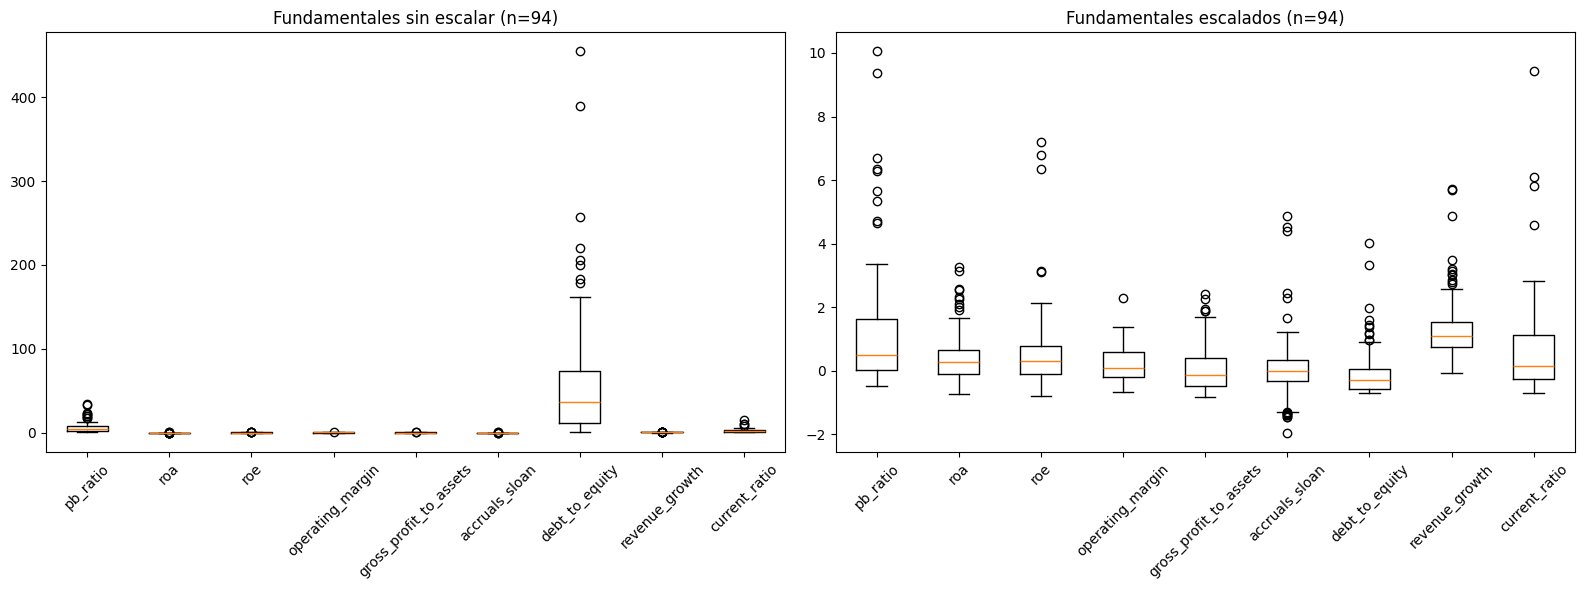

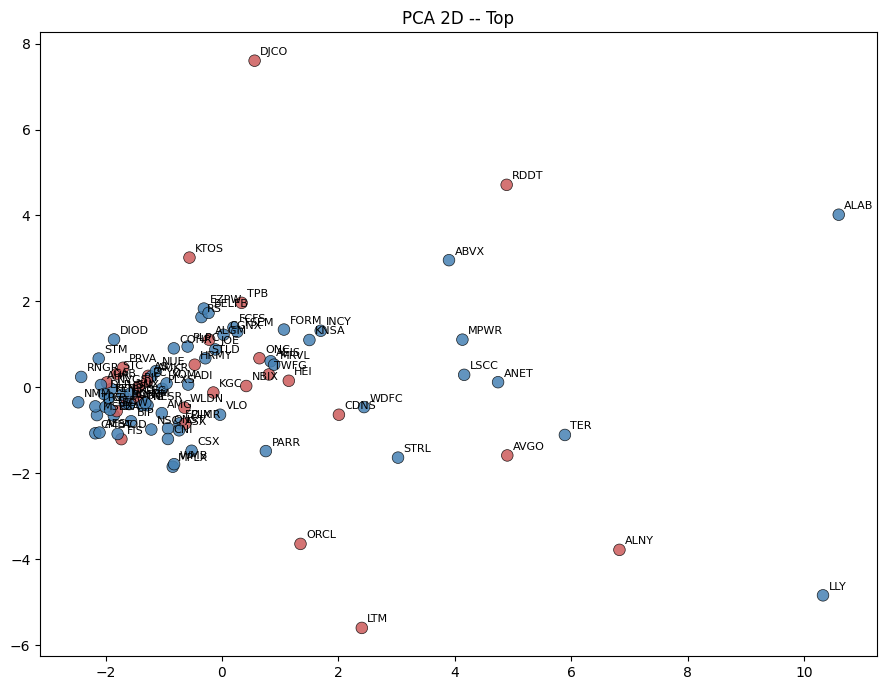

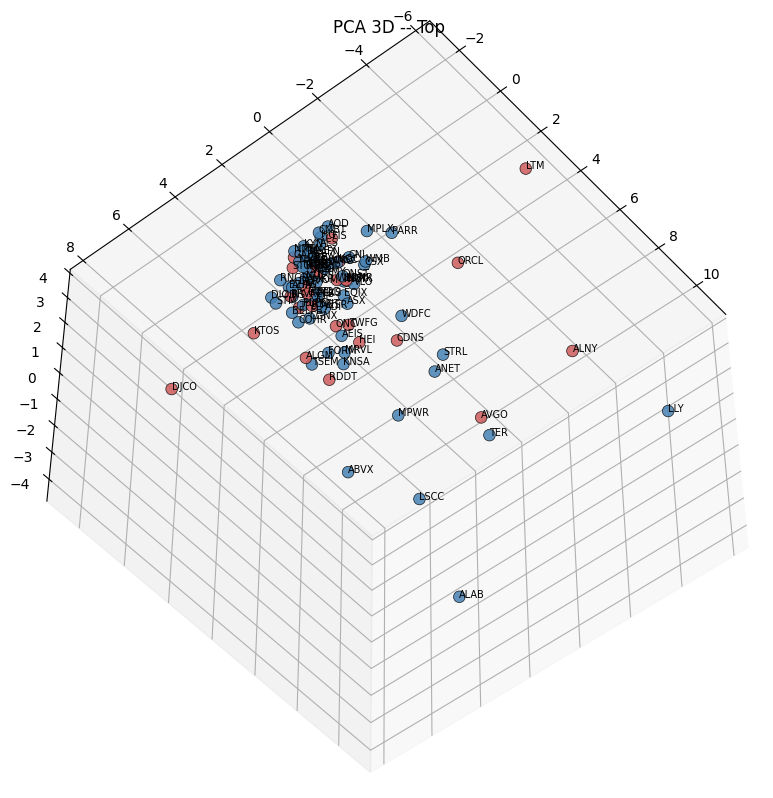

                        count   mean    std    min    25%    50%    75%     max   skew
pb_ratio                 94.0  1.241  2.040 -0.477  0.039  0.488  1.632  10.048  2.349
roa                      94.0  0.459  0.848 -0.741 -0.085  0.267  0.671   3.266  1.351
roe                      94.0  0.599  1.369 -0.792 -0.109  0.313  0.784   7.211  3.130
operating_margin         94.0  0.212  0.533 -0.669 -0.185  0.099  0.600   2.303  0.892
gross_profit_to_assets   94.0  0.070  0.755 -0.811 -0.469 -0.144  0.408   2.403  1.263
accruals_sloan           94.0  0.112  1.124 -1.948 -0.318  0.000  0.331   4.886  2.006
debt_to_equity           94.0 -0.064  0.804 -0.700 -0.570 -0.299  0.046   4.012  2.704
revenue_growth           94.0  1.352  1.073 -0.066  0.753  1.105  1.525   5.725  2.030
current_ratio            94.0  0.689  1.555 -0.692 -0.248  0.158  1.112   9.437  2.975
[INFO] Importancia de variables (árbol de clasificación):
               feature  importance
gross_profit_to_assets    0.312274
  

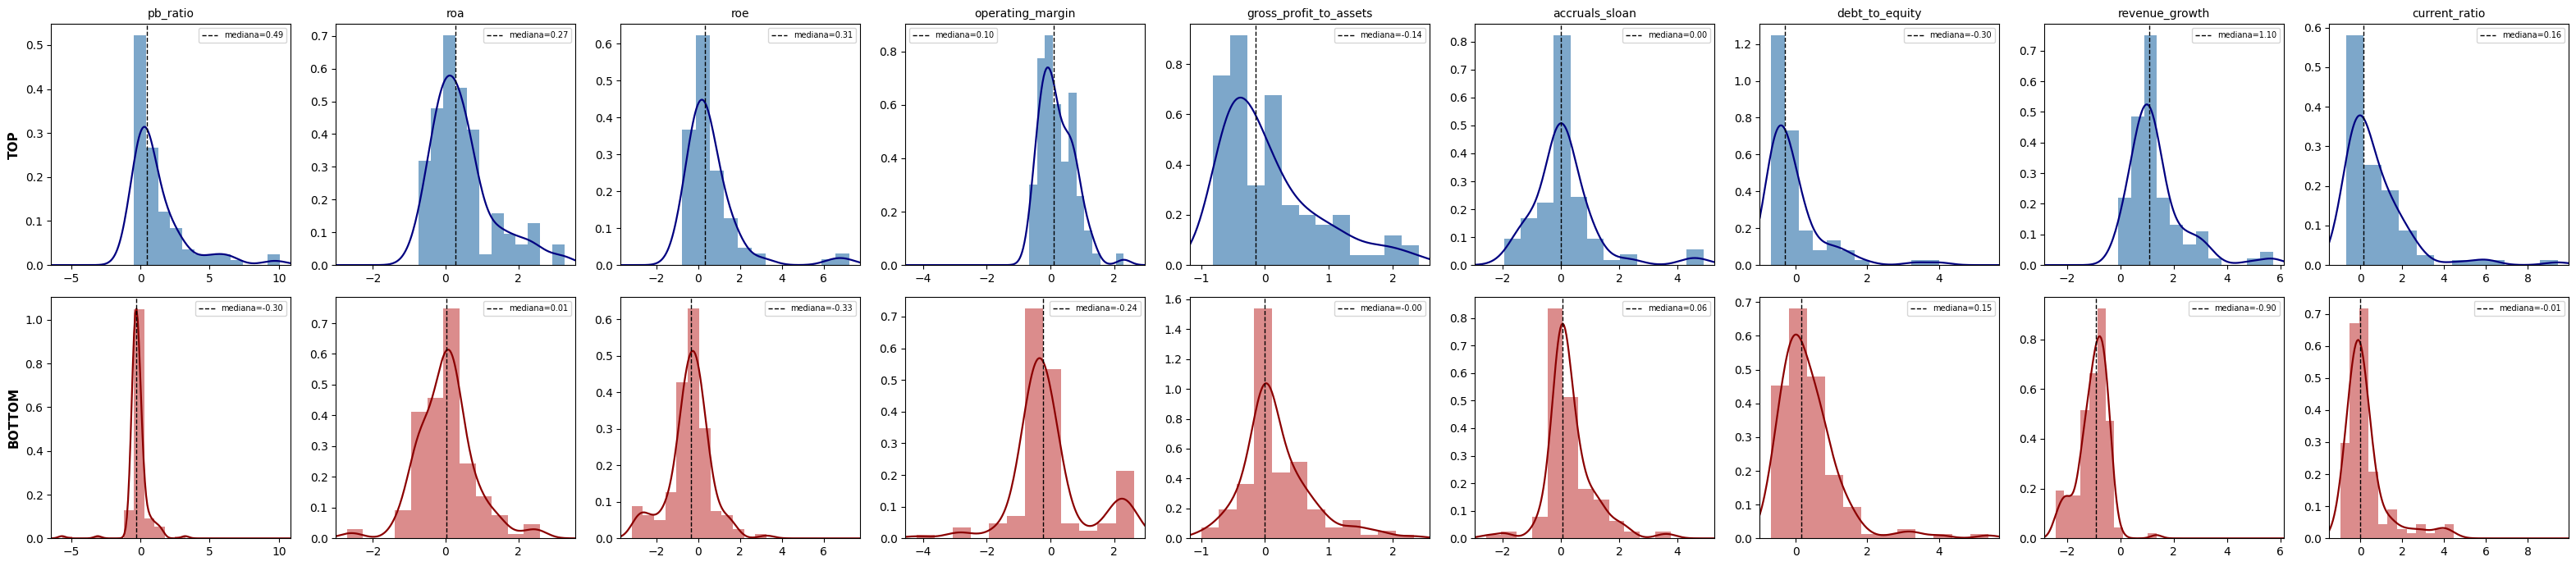

In [ ]:
graficar_boxplot_fundamentales_pool(candidatos_top["ticker"].tolist(), fund_df, df_matrix, FEATURE_COLS)
graficar_pca_2d_pool(candidatos_top, FEATURE_COLS, titulo="Top")
graficar_pca_3d_pool(candidatos_top, FEATURE_COLS, titulo="Top", elev=-50, azim=220)
descriptivas_top = descriptivas_pool(candidatos_top, FEATURE_COLS)
importancia_top = evaluar_importancia_pool(candidatos_top, FEATURE_COLS)
graficar_distribuciones_top_bottom(candidatos_top, candidatos_bottom, FEATURE_COLS)

In [ ]:
def graficar_pca_3d_top_bottom(df_top: pd.DataFrame, df_bottom: pd.DataFrame, feature_cols: list,
                                 elev: int = 20, azim: int = 45):
    """
    PCA 3D ajustado UNA SOLA VEZ sobre la unión de top y bottom -- CUATRO
    series: Top/Y=1, Top/Y=0 (dos tonos de azul) y Bottom/Y=1, Bottom/Y=0
    (dos tonos de rojo) -- permite ver, dentro de cada pool, si los
    aciertos (Y=1) y los fallos (Y=0) del modelo ocupan zonas distintas
    del espacio de fundamentales, además de la separación entre pools.
    """
    if len(feature_cols) < 3:
        raise ValueError("Se necesitan al menos 3 features para PCA 3D.")
    if "Y" not in df_top.columns or "Y" not in df_bottom.columns:
        raise KeyError("df_top y df_bottom necesitan una columna 'Y' para las 4 series.")

    df_top = df_top.copy(); df_top["pool"] = "Top"
    df_bottom = df_bottom.copy(); df_bottom["pool"] = "Bottom"
    combinado = pd.concat([df_top, df_bottom], ignore_index=True)

    X = combinado[feature_cols].values
    pca = PCA(n_components=3, random_state=42)
    scores = pca.fit_transform(X)

    series = [
        ("Top",    1, "navy",         "Top / Y=1"),
        ("Top",    0, "lightskyblue", "Top / Y=0"),
        ("Bottom", 1, "darkred",      "Bottom / Y=1"),
        ("Bottom", 0, "lightsalmon",  "Bottom / Y=0"),
    ]

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    for pool, y_val, color, etiqueta in series:
        mask = ((combinado["pool"] == pool) & (combinado["Y"] == y_val)).values
        if mask.sum() == 0:
            continue
        ax.scatter(scores[mask, 0], scores[mask, 1], scores[mask, 2],
                   s=70, alpha=0.85, c=color, edgecolors="black", linewidths=0.5,
                   label=f"{etiqueta} (n={mask.sum()})")
        if "ticker" in combinado.columns:
            for i in np.where(mask)[0]:
                ax.text(scores[i, 0], scores[i, 1], scores[i, 2], str(combinado["ticker"].iloc[i]), fontsize=6)

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
    ax.set_title(f"PCA 3D -- Top/Bottom x Y (PC1+PC2+PC3={pca.explained_variance_ratio_.sum():.1%})")
    ax.view_init(elev=elev, azim=azim)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

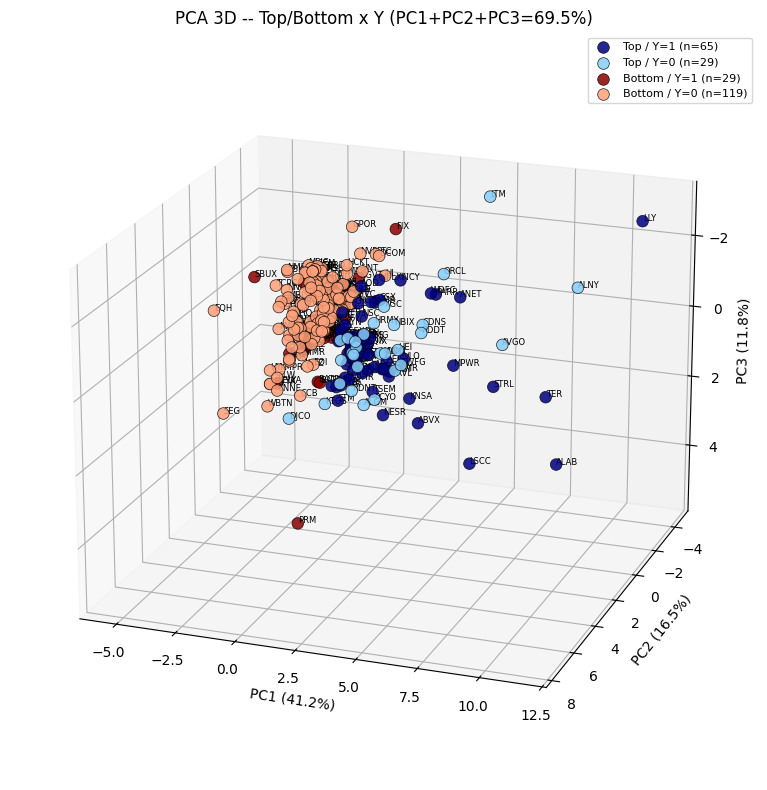

In [ ]:
graficar_pca_3d_top_bottom(candidatos_top, candidatos_bottom, FEATURE_COLS,elev = 200, azim =250)

## Análisis de grafos y centralidad

**Entradas:** lista de tickers, `precios_df`, ventana de fechas, `k_vecinos` o `umbral_corr`.
**Salidas:** `nx.Graph`, diccionario de centralidad, DataFrames de adyacencia/aristas/comunidades.
**Concepto:** nodos = tickers, aristas = correlación de retornos (kNN o umbral fijo);
centralidad de grado/intermediación/cercanía/autovector; comunidades vía Louvain.

In [ ]:
def construir_grafo_correlacion(tickers: list, precios_df: pd.DataFrame, fecha_inicio: str, fecha_fin: str,
                                 umbral_corr: float = 0.5, k_vecinos: int = None,
                                 col_fecha: str = "fecha", col_ticker: str = "ticker", col_precio: str = "close") -> nx.Graph:
    precios = normalizar_precios_df(precios_df, col_fecha)
    precios = precios[precios[col_ticker].isin(tickers)]
    precios = precios[(precios[col_fecha] >= fecha_inicio) & (precios[col_fecha] <= fecha_fin)]
    pivot = precios.pivot(index=col_fecha, columns=col_ticker, values=col_precio).sort_index()
    retornos = pivot.pct_change().dropna(how="all")
    n_dias = len(retornos)
    tickers_ok = [t for t in tickers if t in retornos.columns and retornos[t].notna().sum() >= n_dias * 0.8]
    corr = retornos[tickers_ok].corr()

    G = nx.Graph(); G.add_nodes_from(tickers_ok)
    if k_vecinos is not None:
        for t in tickers_ok:
            vecinos = corr[t].drop(t).abs().sort_values(ascending=False).head(k_vecinos)
            for t2, peso in vecinos.items():
                if not G.has_edge(t, t2):
                    G.add_edge(t, t2, weight=float(peso))
    else:
        for i, t1 in enumerate(tickers_ok):
            for t2 in tickers_ok[i + 1:]:
                c = corr.loc[t1, t2]
                if abs(c) >= umbral_corr:
                    G.add_edge(t1, t2, weight=float(abs(c)))
    print(f"[INFO] Grafo: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")
    return G


def calcular_centralidad(G: nx.Graph, metodo: str = "degree") -> dict:
    if G.number_of_nodes() == 0:
        return {}
    if metodo == "degree": return dict(nx.degree_centrality(G))
    if metodo == "betweenness": return dict(nx.betweenness_centrality(G, weight="weight"))
    if metodo == "closeness": return dict(nx.closeness_centrality(G))
    if metodo == "eigenvector":
        try:
            return dict(nx.eigenvector_centrality(G, weight="weight", max_iter=1000))
        except Exception:
            return dict(nx.degree_centrality(G))
    raise ValueError("metodo invalido")


def graficar_grafo_centralidad(G: nx.Graph, centralidad: dict, cluster_map: dict = None,
                                titulo: str = "Grafo de centralidad", seed: int = 42, escala_nodo: float = 3000, n_etiquetas: int = 15):
    fig, ax = plt.subplots(figsize=(12, 10))
    pos = nx.spring_layout(G, seed=seed, weight="weight")
    tamanos = [centralidad.get(n, 0) * escala_nodo + 20 for n in G.nodes()]
    if cluster_map is not None:
        clusters_unicos = sorted(set(cluster_map.get(n, -999) for n in G.nodes()), key=str)
        cmap = plt.get_cmap("tab20")
        color_map = {c: cmap(i % 20) for i, c in enumerate(clusters_unicos)}
        colores = [color_map[cluster_map.get(n, -999)] for n in G.nodes()]
        handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[c], markersize=8, label=f"Cluster {c}") for c in clusters_unicos]
        ax.legend(handles=handles, loc="upper left", fontsize=8, bbox_to_anchor=(1.0, 1.0))
    else:
        colores = "steelblue"
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.12, width=0.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=tamanos, node_color=colores, alpha=0.85, linewidths=0.3, edgecolors="black")
    top_labels = sorted(centralidad, key=centralidad.get, reverse=True)[:n_etiquetas]
    nx.draw_networkx_labels(G, pos, labels={n: n for n in top_labels}, font_size=7, ax=ax)
    ax.set_title(f"{titulo}\n({G.number_of_nodes()} nodos, {G.number_of_edges()} aristas)"); ax.axis("off")
    plt.tight_layout(); plt.show()


def graficar_grafos_por_cluster(df_clusterizado: pd.DataFrame, precios_df: pd.DataFrame, fecha_inicio: str, fecha_fin: str,
                                 clusters_a_graficar: list = None, k_vecinos: int = 5, metodo_centralidad: str = "degree",
                                 ncols: int = 3, titulo_general: str = "Grafos por cluster"):
    clusters = clusters_a_graficar if clusters_a_graficar is not None else sorted(df_clusterizado["cluster"].unique())
    n = len(clusters); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows), squeeze=False)
    axes = axes.reshape(-1)
    for ax, c in zip(axes, clusters):
        tickers_c = df_clusterizado.loc[df_clusterizado["cluster"] == c, "ticker"].tolist()
        if len(tickers_c) < 5:
            ax.text(0.5, 0.5, "n insuficiente", ha="center", va="center"); ax.set_title(f"Cluster {c}"); ax.axis("off"); continue
        G = construir_grafo_correlacion(tickers_c, precios_df, fecha_inicio, fecha_fin, k_vecinos=k_vecinos)
        cent = calcular_centralidad(G, metodo=metodo_centralidad)
        pos = nx.spring_layout(G, seed=42, weight="weight")
        tamanos = [cent.get(nd, 0) * 2000 + 20 for nd in G.nodes()]
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=0.5)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=tamanos, node_color="steelblue", alpha=0.85, linewidths=0.3, edgecolors="black")
        ax.set_title(f"Cluster {c} (n={len(tickers_c)})", fontsize=10); ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(titulo_general, fontsize=14, y=1.02); plt.tight_layout(); plt.show()


def grafo_a_dataframe_adyacencia(G: nx.Graph) -> pd.DataFrame:
    return nx.to_pandas_adjacency(G, weight="weight")


def grafo_a_dataframe_aristas(G: nx.Graph) -> pd.DataFrame:
    return nx.to_pandas_edgelist(G).sort_values("weight", ascending=False).reset_index(drop=True)


def detectar_comunidades(G: nx.Graph, metodo: str = "louvain") -> pd.DataFrame:
    if metodo == "louvain":
        comunidades = nx.community.louvain_communities(G, weight="weight", seed=42)
    elif metodo == "greedy_modularity":
        comunidades = nx.community.greedy_modularity_communities(G, weight="weight")
    else:
        comunidades = list(nx.community.label_propagation_communities(G))
    filas = [{"ticker": t, "comunidad": i, "tam_comunidad": len(com)} for i, com in enumerate(comunidades) for t in com]
    df = pd.DataFrame(filas).sort_values(["comunidad", "ticker"]).reset_index(drop=True)
    print(f"[INFO] {len(comunidades)} comunidades, tamaños: {sorted([len(c) for c in comunidades], reverse=True)}")
    return df


def seleccionar_representante_por_comunidad(df_comunidades: pd.DataFrame, centralidad: dict) -> pd.DataFrame:
    df = df_comunidades.copy()
    df["centralidad"] = df["ticker"].map(centralidad)
    return df.loc[df.groupby("comunidad")["centralidad"].idxmax()].sort_values("comunidad").reset_index(drop=True)

/tmp/ipykernel_1792/1960840106.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = pivot.pct_change().dropna(how="all")


[INFO] Grafo: 94 nodos, 309 aristas


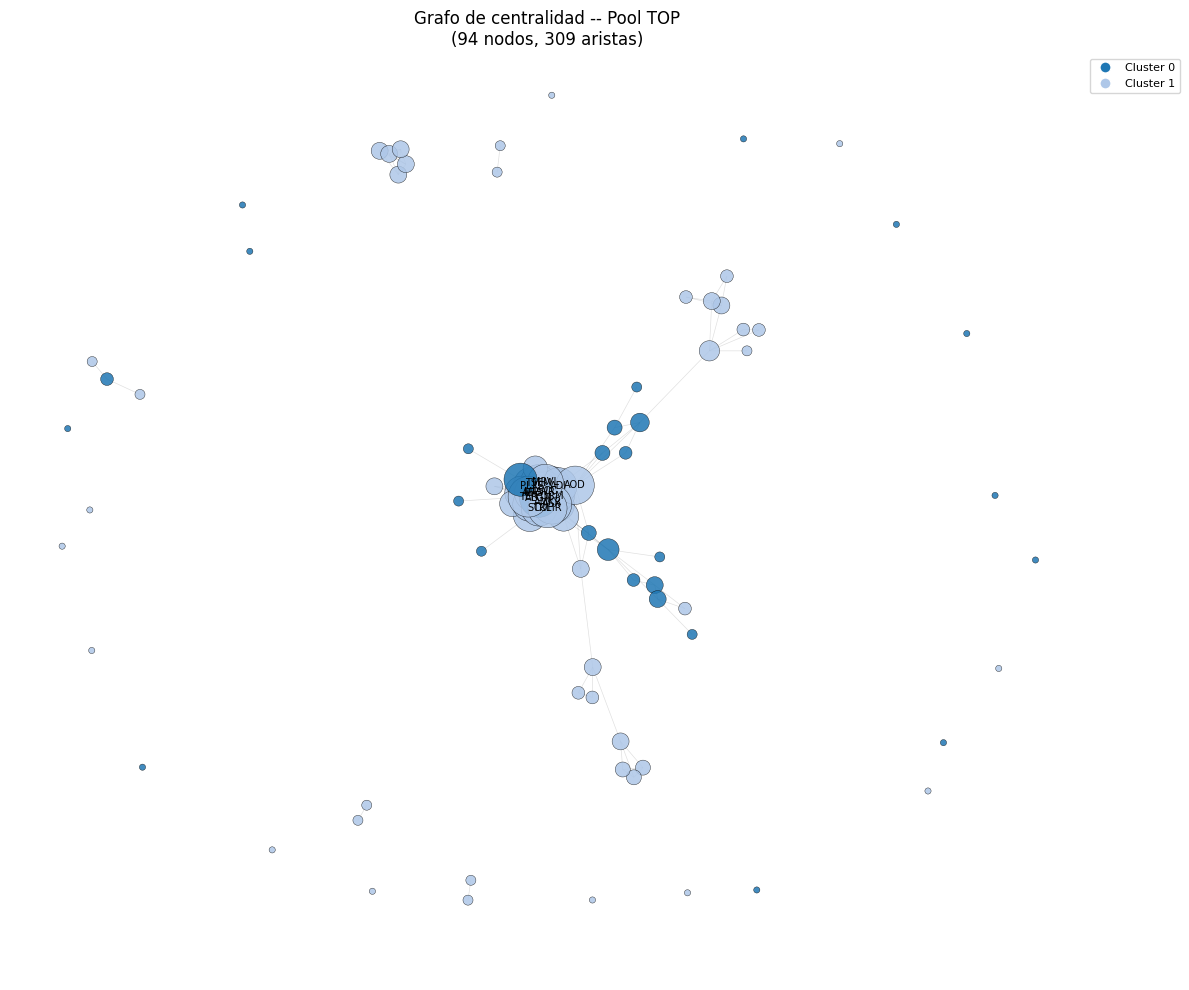

[INFO] 32 comunidades, tamaños: [27, 9, 8, 7, 7, 5, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
FECHA_FIN_GRAFO = fecha_corte.strftime("%Y-%m-%d")
FECHA_INICIO_GRAFO = (fecha_corte - pd.Timedelta(days=365)).strftime("%Y-%m-%d")

G_top = construir_grafo_correlacion(candidatos_top["ticker"].tolist(), precios_df, FECHA_INICIO_GRAFO, FECHA_FIN_GRAFO, k_vecinos=None, umbral_corr=0.4)
centralidad_top = calcular_centralidad(G_top, metodo="degree")
y_map_top = candidatos_top.set_index("ticker")["Y"].to_dict()
graficar_grafo_centralidad(G_top, centralidad_top, cluster_map=y_map_top, titulo="Grafo de centralidad -- Pool TOP")

comunidades_top = detectar_comunidades(G_top, metodo="louvain")
representantes_top = seleccionar_representante_por_comunidad(comunidades_top, centralidad_top)

## Portafolios y métricas de desempeño

**Entradas:** lista de tickers, `precios_df`, ventana de fechas, `rf_anual`.
**Salidas:** pesos por ticker, retornos diarios, tabla comparativa (Sharpe,
Sortino, drawdown máximo, beta, alpha de Jensen), gráfico de retornos acumulados.
**Concepto:** portafolio de mínima varianza (`scipy.optimize`, `long_only`) y
portafolio de pesos iguales; métricas de desempeño estándar sobre la serie de
retornos diarios resultante.

In [ ]:
def calcular_portafolio_min_varianza(tickers: list, precios_df: pd.DataFrame, fecha_inicio: str, fecha_fin: str,
                                      long_only: bool = True, col_fecha: str = "fecha", col_ticker: str = "ticker", col_precio: str = "close") -> pd.DataFrame:
    precios = normalizar_precios_df(precios_df, col_fecha)
    precios = precios[precios[col_ticker].isin(tickers)]
    precios = precios[(precios[col_fecha] >= fecha_inicio) & (precios[col_fecha] <= fecha_fin)]
    pivot = precios.pivot(index=col_fecha, columns=col_ticker, values=col_precio).sort_index()
    n_dias = len(pivot)
    tickers_ok = [t for t in tickers if t in pivot.columns and pivot[t].notna().sum() >= n_dias * 0.8]
    retornos = pivot[tickers_ok].pct_change().dropna(how="all").fillna(0)
    cov = retornos.cov() * 252
    n = cov.shape[0]
    def varianza(w): return w @ cov.values @ w
    bounds = [(0, 1)] * n if long_only else [(-1, 1)] * n
    resultado = minimize(varianza, np.repeat(1 / n, n), method="SLSQP", bounds=bounds,
                          constraints=[{"type": "eq", "fun": lambda w: np.sum(w) - 1}], options={"maxiter": 500, "ftol": 1e-10})
    pesos = pd.DataFrame({"ticker": cov.columns, "peso": resultado.x})
    pesos = pesos[pesos["peso"] > 1e-4].sort_values("peso", ascending=False).reset_index(drop=True)
    print(f"[INFO] Portafolio min-varianza: {len(pesos)}/{n} tickers con peso>0, vol. anualizada={np.sqrt(varianza(resultado.x)):.2%}")
    return pesos


def calcular_portafolio_pesos_iguales(tickers: list, precios_df: pd.DataFrame, fecha_inicio: str, fecha_fin: str,
                                       col_fecha: str = "fecha", col_ticker: str = "ticker", col_precio: str = "close") -> pd.DataFrame:
    precios = normalizar_precios_df(precios_df, col_fecha)
    precios = precios[precios[col_ticker].isin(tickers)]
    precios = precios[(precios[col_fecha] >= fecha_inicio) & (precios[col_fecha] <= fecha_fin)]
    pivot = precios.pivot(index=col_fecha, columns=col_ticker, values=col_precio).sort_index()
    n_dias = len(pivot)
    tickers_ok = [t for t in tickers if t in pivot.columns and pivot[t].notna().sum() >= n_dias * 0.8]
    peso = 1 / len(tickers_ok) if tickers_ok else 0
    pesos = pd.DataFrame({"ticker": tickers_ok, "peso": peso})
    print(f"[INFO] Portafolio de pesos iguales: {len(pesos)} tickers, peso={peso:.4f} cada uno")
    return pesos


def calcular_retornos_portafolio(pesos: pd.DataFrame, precios_df: pd.DataFrame, fecha_inicio: str, fecha_fin: str,
                                  col_fecha: str = "fecha", col_ticker: str = "ticker", col_precio: str = "close") -> pd.Series:
    tickers = pesos["ticker"].tolist()
    w = pesos.set_index("ticker")["peso"]
    precios = normalizar_precios_df(precios_df, col_fecha)
    precios = precios[precios[col_ticker].isin(tickers)]
    precios = precios[(precios[col_fecha] >= fecha_inicio) & (precios[col_fecha] <= fecha_fin)]
    pivot = precios.pivot(index=col_fecha, columns=col_ticker, values=col_precio).sort_index()
    retornos = pivot[tickers].pct_change().fillna(0)
    return (retornos * w).sum(axis=1)


def calcular_metricas_desempeno(retornos_diarios: pd.Series, retornos_benchmark: pd.Series, rf_anual: float) -> dict:
    r = retornos_diarios.dropna()
    rb = retornos_benchmark.reindex(r.index).dropna()
    r = r.reindex(rb.index).dropna()
    rf_diario = (1 + rf_anual) ** (1 / 252) - 1
    exceso = r - rf_diario
    vol_anual = r.std() * np.sqrt(252)
    media_exceso_anual = exceso.mean() * 252
    sharpe = media_exceso_anual / vol_anual if vol_anual > 0 else np.nan
    downside = exceso[exceso < 0]
    downside_dev_anual = downside.std() * np.sqrt(252) if len(downside) > 1 else np.nan
    sortino = media_exceso_anual / downside_dev_anual if downside_dev_anual and downside_dev_anual > 0 else np.nan
    riqueza = (1 + r).cumprod()
    max_drawdown = ((riqueza - riqueza.cummax()) / riqueza.cummax()).min()
    exceso_bench = rb - rf_diario
    if exceso_bench.var() > 0 and len(exceso) > 2:
        beta = np.cov(exceso, exceso_bench)[0, 1] / np.var(exceso_bench)
        jensen_alpha_anual = (exceso.mean() - beta * exceso_bench.mean()) * 252
    else:
        beta, jensen_alpha_anual = np.nan, np.nan
    ret_total = riqueza.iloc[-1] - 1 if len(riqueza) else np.nan
    ret_anualizado = (1 + ret_total) ** (252 / len(r)) - 1 if len(r) > 0 else np.nan
    return {"retorno_total": ret_total, "retorno_anualizado": ret_anualizado, "volatilidad_anual": vol_anual,
            "sharpe": sharpe, "sortino": sortino, "max_drawdown": max_drawdown, "beta": beta,
            "jensen_alpha_anual": jensen_alpha_anual, "n_dias": len(r)}


def tabla_comparativa_portafolios(dict_retornos: dict, retornos_benchmark: pd.Series, rf_anual: float) -> pd.DataFrame:
    filas = []
    for nombre, serie in dict_retornos.items():
        m = calcular_metricas_desempeno(serie, retornos_benchmark, rf_anual); m["portafolio"] = nombre
        filas.append(m)
    m_bench = calcular_metricas_desempeno(retornos_benchmark, retornos_benchmark, rf_anual); m_bench["portafolio"] = "Benchmark"
    filas.append(m_bench)
    tabla = pd.DataFrame(filas).set_index("portafolio")
    tabla = tabla[["retorno_total", "retorno_anualizado", "volatilidad_anual", "sharpe", "sortino",
                   "max_drawdown", "beta", "jensen_alpha_anual", "n_dias"]]
    print(tabla.round(4).to_string())
    return tabla


def graficar_retornos_acumulados(dict_retornos: dict, retornos_benchmark: pd.Series):
    fig, ax = plt.subplots(figsize=(11, 6))
    for nombre, serie in dict_retornos.items():
        riqueza = (1 + serie.dropna()).cumprod()
        ax.plot(riqueza.index, riqueza.values - 1, label=nombre, linewidth=1.8)
    riqueza_bench = (1 + retornos_benchmark.dropna()).cumprod()
    ax.plot(riqueza_bench.index, riqueza_bench.values - 1, label="Benchmark", linewidth=1.8, linestyle="--", color="black")
    ax.set_ylabel("Retorno acumulado")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title("Retornos acumulados -- portafolios vs. benchmark")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

/tmp/ipykernel_1792/3490222037.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = pivot[tickers_ok].pct_change().dropna(how="all").fillna(0)


[INFO] Portafolio min-varianza: 36/94 tickers con peso>0, vol. anualizada=7.79%


/tmp/ipykernel_1792/3490222037.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = pivot[tickers_ok].pct_change().dropna(how="all").fillna(0)


[INFO] Portafolio min-varianza: 23/148 tickers con peso>0, vol. anualizada=5.38%
[INFO] Portafolio de pesos iguales: 94 tickers, peso=0.0106 cada uno
[INFO] Portafolio de pesos iguales: 148 tickers, peso=0.0068 cada uno


/tmp/ipykernel_1792/3490222037.py:44: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = pivot[tickers].pct_change().fillna(0)
/tmp/ipykernel_1792/3490222037.py:44: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = pivot[tickers].pct_change().fillna(0)
/tmp/ipykernel_1792/3490222037.py:44: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = pivot[tickers].pct_change().filln

        Top - MinVar  Top - Equal  Bottom - MinVar  Bottom - Equal
ticker                                                            
GAB           0.1017       0.0106           0.0000          0.0000
XOM           0.0857       0.0106           0.0000          0.0000
MPLX          0.0842       0.0106           0.0000          0.0000
AOD           0.0746       0.0106           0.0000          0.0000
AHR           0.0586       0.0106           0.0000          0.0000
WDFC          0.0566       0.0106           0.0000          0.0000
PBA           0.0555       0.0106           0.0000          0.0000
MSEX          0.0482       0.0106           0.0000          0.0000
EQIX          0.0460       0.0106           0.0000          0.0000
TTE           0.0368       0.0106           0.0000          0.0000
TWFG          0.0346       0.0106           0.0000          0.0000
FIS           0.0258       0.0106           0.0000          0.0000
AVGO          0.0245       0.0106           0.0000          0.

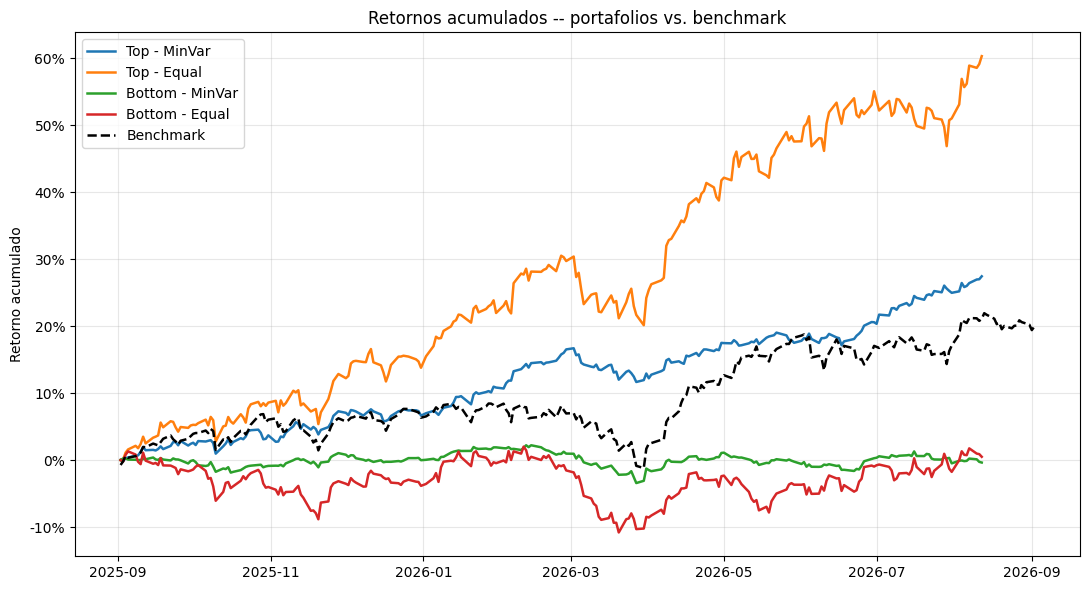

In [ ]:
FECHA_INICIO_PORTAFOLIO = FECHA_INICIO_GRAFO
FECHA_FIN_PORTAFOLIO = FECHA_FIN_GRAFO

tickers_top = candidatos_top["ticker"].tolist()
tickers_bottom = candidatos_bottom["ticker"].tolist()

pesos_top_minvar = calcular_portafolio_min_varianza(tickers_top, precios_df, FECHA_INICIO_PORTAFOLIO, FECHA_FIN_PORTAFOLIO)
pesos_bottom_minvar = calcular_portafolio_min_varianza(tickers_bottom, precios_df, FECHA_INICIO_PORTAFOLIO, FECHA_FIN_PORTAFOLIO)
pesos_top_iguales = calcular_portafolio_pesos_iguales(tickers_top, precios_df, FECHA_INICIO_PORTAFOLIO, FECHA_FIN_PORTAFOLIO)
pesos_bottom_iguales = calcular_portafolio_pesos_iguales(tickers_bottom, precios_df, FECHA_INICIO_PORTAFOLIO, FECHA_FIN_PORTAFOLIO)

ret_top_minvar = calcular_retornos_portafolio(pesos_top_minvar, precios_df, FECHA_INICIO_PORTAFOLIO, FECHA_FIN_PORTAFOLIO)
ret_bottom_minvar = calcular_retornos_portafolio(pesos_bottom_minvar, precios_df, FECHA_INICIO_PORTAFOLIO, FECHA_FIN_PORTAFOLIO)
ret_top_iguales = calcular_retornos_portafolio(pesos_top_iguales, precios_df, FECHA_INICIO_PORTAFOLIO, FECHA_FIN_PORTAFOLIO)
ret_bottom_iguales = calcular_retornos_portafolio(pesos_bottom_iguales, precios_df, FECHA_INICIO_PORTAFOLIO, FECHA_FIN_PORTAFOLIO)

bench_df = normalizar_precios_df(precios_df[precios_df["ticker"] == "SPY"])
ret_bench = bench_df.set_index("fecha")["close"].pct_change()
ret_bench = ret_bench[(ret_bench.index >= FECHA_INICIO_PORTAFOLIO) & (ret_bench.index <= FECHA_FIN_PORTAFOLIO)]

dict_retornos = {"Top - MinVar": ret_top_minvar, "Top - Equal": ret_top_iguales,
                 "Bottom - MinVar": ret_bottom_minvar, "Bottom - Equal": ret_bottom_iguales}

tabla_pesos = pd.concat([
    pesos_top_minvar.set_index("ticker")["peso"].rename("Top - MinVar"),
    pesos_top_iguales.set_index("ticker")["peso"].rename("Top - Equal"),
    pesos_bottom_minvar.set_index("ticker")["peso"].rename("Bottom - MinVar"),
    pesos_bottom_iguales.set_index("ticker")["peso"].rename("Bottom - Equal"),
], axis=1).fillna(0)
print(tabla_pesos.round(4).to_string())

tabla_portafolios = tabla_comparativa_portafolios(dict_retornos, ret_bench, RF_ANNUAL)
graficar_retornos_acumulados(dict_retornos, ret_bench)